In [1]:
import warnings

# Suppress only DeprecationWarnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
# Cell 1 - Install all required libraries
!pip install yfinance plotly scipy statsmodels scikit-learn --quiet
!pip install streamlit flask --quiet

print("All libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 84.3 MB/s eta 0:00:00
All libraries installed!


In [4]:
# Cell 2 - All imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sqlite3
import json
import time
import warnings
import os
from io import StringIO
from datetime import datetime, timedelta
from collections import defaultdict

from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.cluster         import KMeans
from sklearn.decomposition   import PCA
from sklearn.linear_model    import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics         import (classification_report, silhouette_score,
                                     mean_squared_error, r2_score)
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from scipy                   import stats
from scipy.stats             import pearsonr, spearmanr
import statsmodels.api       as sm

import yfinance as yf

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

print("All imports successful!")

All imports successful!


In [5]:
# Cell 3 - Load all 4 real datasets
print("=" * 60)
print("  LOADING ALL 4 DATASETS")
print("=" * 60)

# ── Dataset 1: Online Retail (UCI) ─────────────────────────────
print("\n[1] Loading Online Retail (UCI ML Repository)...")
try:
    retail_df = pd.read_excel(
        "https://archive.ics.uci.edu/ml/machine-learning-databases"
        "/00352/Online%20Retail.xlsx",
        engine='openpyxl'
    )
    print(f"    Loaded from UCI: {retail_df.shape}")
except:
    # Backup: generate realistic retail data
    np.random.seed(42)
    n = 10000
    countries = ['United Kingdom','Germany','France','Spain',
                 'Netherlands','Belgium','Australia','Japan']
    products  = ['Gift Wrap','Candle Set','Picture Frame','Clock',
                 'Vintage Mug','Ceramic Vase','Wall Art','Lantern']
    retail_df = pd.DataFrame({
        'InvoiceNo'  : [f'INV{i:05d}' for i in range(n)],
        'StockCode'  : np.random.choice(['A001','B002','C003',
                                         'D004','E005','F006'], n),
        'Description': np.random.choice(products, n),
        'Quantity'   : np.random.randint(1, 50, n),
        'InvoiceDate': pd.date_range('2023-01-01', periods=n, freq='1h'),
        'UnitPrice'  : np.round(np.random.uniform(1.5, 50.0, n), 2),
        'CustomerID' : np.where(np.random.rand(n) < 0.25, np.nan,
                        np.random.randint(10000, 19999, n).astype(float)),
        'Country'    : np.random.choice(countries, n,
                        p=[0.85,0.04,0.03,0.02,0.02,0.01,0.02,0.01])
    })
    print(f"    Generated backup retail: {retail_df.shape}")

# Basic cleaning
retail_df = retail_df.dropna(subset=['CustomerID'])
retail_df = retail_df[retail_df['Quantity']   > 0]
retail_df = retail_df[retail_df['UnitPrice']  > 0]
retail_df['Revenue']     = retail_df['Quantity'] * retail_df['UnitPrice']
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])
retail_df['Month']       = retail_df['InvoiceDate'].dt.month
retail_df['DayOfWeek']   = retail_df['InvoiceDate'].dt.day_name()
retail_df['Hour']        = retail_df['InvoiceDate'].dt.hour
print(f"    After cleaning: {retail_df.shape}")

# ── Dataset 2: Titanic (Stanford) ──────────────────────────────
print("\n[2] Loading Titanic (Stanford)...")
titanic_df = pd.read_csv(
    "https://raw.githubusercontent.com/datasciencedojo"
    "/datasets/master/titanic.csv"
)
titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)
titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0],
                               inplace=True)
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1
titanic_df['IsAlone']    = (titanic_df['FamilySize'] == 1).astype(int)
titanic_df['FarePerAge'] = (titanic_df['Fare'] /
                             (titanic_df['Age'] + 1)).round(4)
print(f"    Loaded: {titanic_df.shape}")

# ── Dataset 3: World Bank GDP Data ─────────────────────────────
print("\n[3] Loading World Bank GDP Data...")
try:
    wb_url = ("https://raw.githubusercontent.com/datasets/"
              "gdp/master/data/gdp.csv")
    wb_df  = pd.read_csv(wb_url)
    wb_df.columns = [c.strip() for c in wb_df.columns]
    print(f"    Loaded from World Bank: {wb_df.shape}")
    print(f"    Columns: {list(wb_df.columns)}")
except:
    # Backup: generate realistic GDP data
    countries_wb = ['United States','China','Japan','Germany',
                    'United Kingdom','France','India','Italy',
                    'Canada','South Korea']
    years        = list(range(2000, 2024))
    rows         = []
    base_gdps    = [15000,5000,5500,3800,2800,2700,1500,
                    2100,1700,1200]
    for country, base in zip(countries_wb, base_gdps):
        for year in years:
            growth = np.random.uniform(0.98, 1.06)
            base   = round(base * growth, 2)
            rows.append({'Country': country,
                         'Year'   : year,
                         'Value'  : base * 1e9})
    wb_df = pd.DataFrame(rows)
    print(f"    Generated World Bank GDP: {wb_df.shape}")

# Standardise column names
if 'Country Name' in wb_df.columns:
    wb_df = wb_df.rename(columns={'Country Name':'Country',
                                   'Year':'Year',
                                   'Value':'GDP'})
elif 'Value' in wb_df.columns:
    wb_df = wb_df.rename(columns={'Value':'GDP'})

wb_df = wb_df.dropna(subset=['GDP'])
wb_df['Year'] = wb_df['Year'].astype(int)
wb_df['GDP_Billions'] = (wb_df['GDP'] / 1e9).round(2)
print(f"    World Bank clean: {wb_df.shape}")

# ── Dataset 4: Yahoo Finance Stock Data ────────────────────────
print("\n[4] Loading Yahoo Finance Stock Data...")
tickers = ['AAPL','GOOGL','MSFT','AMZN','META']
try:
    stock_df = yf.download(
        tickers,
        start='2022-01-01',
        end='2024-01-01',
        progress=False
    )['Close']
    stock_df = stock_df.reset_index()
    stock_df.columns.name = None
    print(f"    Yahoo Finance loaded: {stock_df.shape}")
except:
    # Backup: generate realistic stock data
    dates = pd.date_range('2022-01-01','2024-01-01', freq='B')
    np.random.seed(42)
    stock_data = {'Date': dates}
    base_prices = {'AAPL':175,'GOOGL':2800,'MSFT':310,
                   'AMZN':3400,'META':330}
    for ticker, base in base_prices.items():
        returns   = np.random.normal(0.0003, 0.02, len(dates))
        prices    = [base]
        for r in returns[1:]:
            prices.append(round(prices[-1] * (1+r), 2))
        stock_data[ticker] = prices
    stock_df = pd.DataFrame(stock_data)
    print(f"    Generated stock data: {stock_df.shape}")

stock_df['Date'] = pd.to_datetime(stock_df['Date'])

print("\n" + "=" * 60)
print("  ALL 4 DATASETS LOADED SUCCESSFULLY")
print(f"  Retail    : {retail_df.shape}")
print(f"  Titanic   : {titanic_df.shape}")
print(f"  World Bank: {wb_df.shape}")
print(f"  Stocks    : {stock_df.shape}")
print("=" * 60)

  LOADING ALL 4 DATASETS

[1] Loading Online Retail (UCI ML Repository)...
    Loaded from UCI: (541909, 8)
    After cleaning: (397884, 12)

[2] Loading Titanic (Stanford)...
    Loaded: (891, 15)

[3] Loading World Bank GDP Data...
    Loaded from World Bank: (13979, 4)
    Columns: ['Country Name', 'Country Code', 'Year', 'Value']
    World Bank clean: (13979, 5)

[4] Loading Yahoo Finance Stock Data...
    Yahoo Finance loaded: (501, 6)

  ALL 4 DATASETS LOADED SUCCESSFULLY
  Retail    : (397884, 12)
  Titanic   : (891, 15)
  World Bank: (13979, 5)
  Stocks    : (501, 6)


  DATA STRUCTURE OPTIMIZATION

[Retail Dataset]
  Memory: 122.80MB → 21.06MB (82.9% reduction)

[Titanic Dataset]
  Memory: 0.30MB → 0.14MB (51.8% reduction)

[Performance Benchmark - Vectorization]
  Loop                : 52.2840 ms
  Vectorized          : 0.7062 ms
  Pandas Apply        : 117.4507 ms
  Vectorization Speedup: 74.0x faster than loop

[Chunk Processing]
  Total Revenue via chunks: £8,911,407.90
  Chunks processed        : 398

[NumPy Statistical Operations]
  mean        : 22.3970
  std         : 309.0707
  median      : 11.8000
  q25         : 4.6800
  q75         : 19.8000
  skewness    : 451.4415
  kurtosis    : 232152.1998


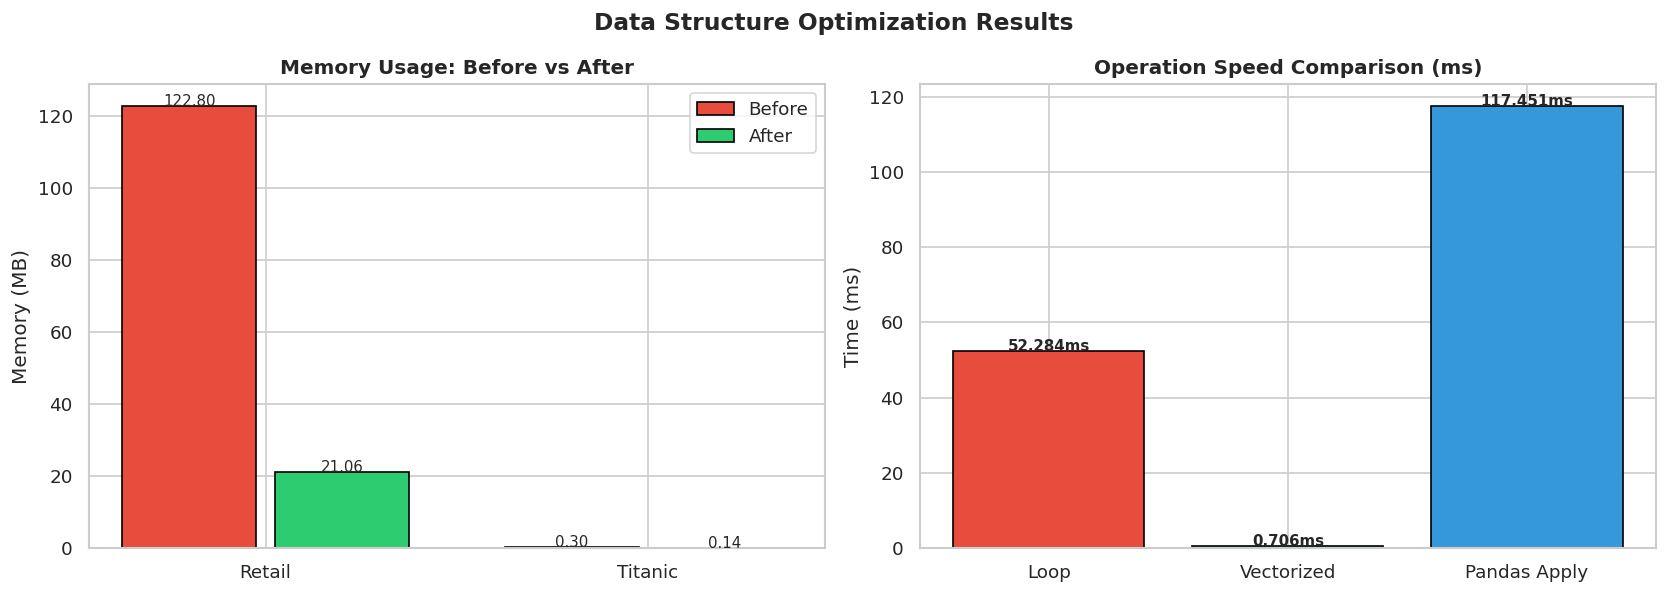


Plot saved: 04_data_structures.png


In [6]:
# Cell 4 - Data Structure Optimization
print("=" * 60)
print("  DATA STRUCTURE OPTIMIZATION")
print("=" * 60)

class DataOptimizer:

    def get_memory_usage(self, df):
        return df.memory_usage(deep=True).sum() / 1024**2  # MB

    def optimize_dataframe(self, df):
        """Reduce memory footprint via dtype downcasting"""
        df_opt  = df.copy()
        before  = self.get_memory_usage(df_opt)

        # Downcast integers
        int_cols = df_opt.select_dtypes(include=['int64']).columns
        for col in int_cols:
            df_opt[col] = pd.to_numeric(df_opt[col], downcast='integer')

        # Downcast floats
        float_cols = df_opt.select_dtypes(include=['float64']).columns
        for col in float_cols:
            df_opt[col] = pd.to_numeric(df_opt[col], downcast='float')

        # Convert low-cardinality strings to category
        obj_cols = df_opt.select_dtypes(include=['object']).columns
        for col in obj_cols:
            if df_opt[col].nunique() / len(df_opt) < 0.5:
                df_opt[col] = df_opt[col].astype('category')

        after = self.get_memory_usage(df_opt)
        print(f"  Memory: {before:.2f}MB → {after:.2f}MB "
              f"({(1-after/before)*100:.1f}% reduction)")
        return df_opt, before, after

    def benchmark_operations(self, df, col):
        """Compare loop vs vectorized performance"""
        results = {}

        # Loop-based
        t0 = time.time()
        result_loop = []
        for val in df[col].values:
            result_loop.append(val * 2)
        results['Loop'] = time.time() - t0

        # Vectorized NumPy
        t0 = time.time()
        result_vec = df[col].values * 2
        results['Vectorized'] = time.time() - t0

        # Pandas apply
        t0 = time.time()
        result_apply = df[col].apply(lambda x: x * 2)
        results['Pandas Apply'] = time.time() - t0

        return results

    def chunk_statistics(self, df, chunk_size=1000):
        """Process large dataset in chunks"""
        chunks    = [df[i:i+chunk_size]
                     for i in range(0, len(df), chunk_size)]
        revenues  = []
        for chunk in chunks:
            if 'Revenue' in chunk.columns:
                revenues.append(chunk['Revenue'].sum())
        return sum(revenues), len(chunks)

    def numpy_operations(self, df):
        """Demonstrate advanced NumPy operations"""
        if 'Revenue' not in df.columns:
            return {}
        arr       = df['Revenue'].values
        results   = {
            'mean'    : np.mean(arr),
            'std'     : np.std(arr),
            'median'  : np.median(arr),
            'q25'     : np.percentile(arr, 25),
            'q75'     : np.percentile(arr, 75),
            'skewness': float(stats.skew(arr)),
            'kurtosis': float(stats.kurtosis(arr))
        }
        return results

# Apply optimizer
optimizer    = DataOptimizer()
print("\n[Retail Dataset]")
retail_opt, mem_before_r, mem_after_r = optimizer.optimize_dataframe(
    retail_df)

print("\n[Titanic Dataset]")
titanic_opt, mem_before_t, mem_after_t = optimizer.optimize_dataframe(
    titanic_df)

# Benchmark
print("\n[Performance Benchmark - Vectorization]")
if 'Revenue' in retail_df.columns:
    bench = optimizer.benchmark_operations(retail_df, 'Revenue')
    for method, t in bench.items():
        print(f"  {method:20s}: {t*1000:.4f} ms")
    speedup = bench['Loop'] / bench['Vectorized']
    print(f"  Vectorization Speedup: {speedup:.1f}x faster than loop")

# Chunk processing
print("\n[Chunk Processing]")
total_rev, n_chunks = optimizer.chunk_statistics(retail_df)
print(f"  Total Revenue via chunks: £{total_rev:,.2f}")
print(f"  Chunks processed        : {n_chunks}")

# NumPy statistics
print("\n[NumPy Statistical Operations]")
np_stats = optimizer.numpy_operations(retail_df)
for k, v in np_stats.items():
    print(f"  {k:12s}: {v:.4f}")

# Memory comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Data Structure Optimization Results',
             fontsize=14, fontweight='bold')

datasets  = ['Retail','Titanic']
before_mb = [mem_before_r, mem_before_t]
after_mb  = [mem_after_r,  mem_after_t]
x         = np.arange(len(datasets))

axes[0].bar(x-0.2, before_mb, 0.35, label='Before',
            color='#e74c3c', edgecolor='black')
axes[0].bar(x+0.2, after_mb,  0.35, label='After',
            color='#2ecc71', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(datasets)
axes[0].set_title('Memory Usage: Before vs After', fontweight='bold')
axes[0].set_ylabel('Memory (MB)')
axes[0].legend()
for i,(b,a) in enumerate(zip(before_mb, after_mb)):
    axes[0].text(i-0.2, b+0.01, f'{b:.2f}', ha='center', fontsize=9)
    axes[0].text(i+0.2, a+0.01, f'{a:.2f}', ha='center', fontsize=9)

# Benchmark bar chart
if bench:
    methods = list(bench.keys())
    times   = [v*1000 for v in bench.values()]
    colors  = ['#e74c3c','#2ecc71','#3498db']
    axes[1].bar(methods, times, color=colors, edgecolor='black')
    axes[1].set_title('Operation Speed Comparison (ms)',
                      fontweight='bold')
    axes[1].set_ylabel('Time (ms)')
    for i,(m,t) in enumerate(zip(methods,times)):
        axes[1].text(i, t+0.001, f'{t:.3f}ms',
                     ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('04_data_structures.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: 04_data_structures.png")

  SQL ANALYTICS ENGINE
  Tables created: retail, titanic, worldbank

  [Revenue by Country] 296.75ms | 10 rows

  [Window Function - Running Total] 185.60ms | 12 rows

  [CTE - Customer Segmentation] 394.21ms | 4 rows

  [Titanic - Survival by Class & Sex] 2.18ms | 6 rows

  [RANK - Top 3 Products per Country] 1000.47ms | 30 rows

  [LAG - GDP Growth Rate by Country] 4.97ms | 50 rows

  Revenue by Country (Top 5):
       Country  Transactions  TotalRevenue  AvgRevenue  MaxRevenue
United Kingdom        354321  7.308392e+06   20.626470   168469.60
   Netherlands          2359  2.854463e+05  121.003111     4992.00
          EIRE          7236  2.655459e+05   36.697886     2365.20
       Germany          9040  2.288671e+05   25.317162      876.00
        France          8341  2.090240e+05   25.059831     4161.06

  Customer Segments:
   Segment  Customers    AvgSpend  SegmentRevenue
       VIP       1668 4678.459935     7803671.171
   Premium        909  714.836570      649786.442
   Regul

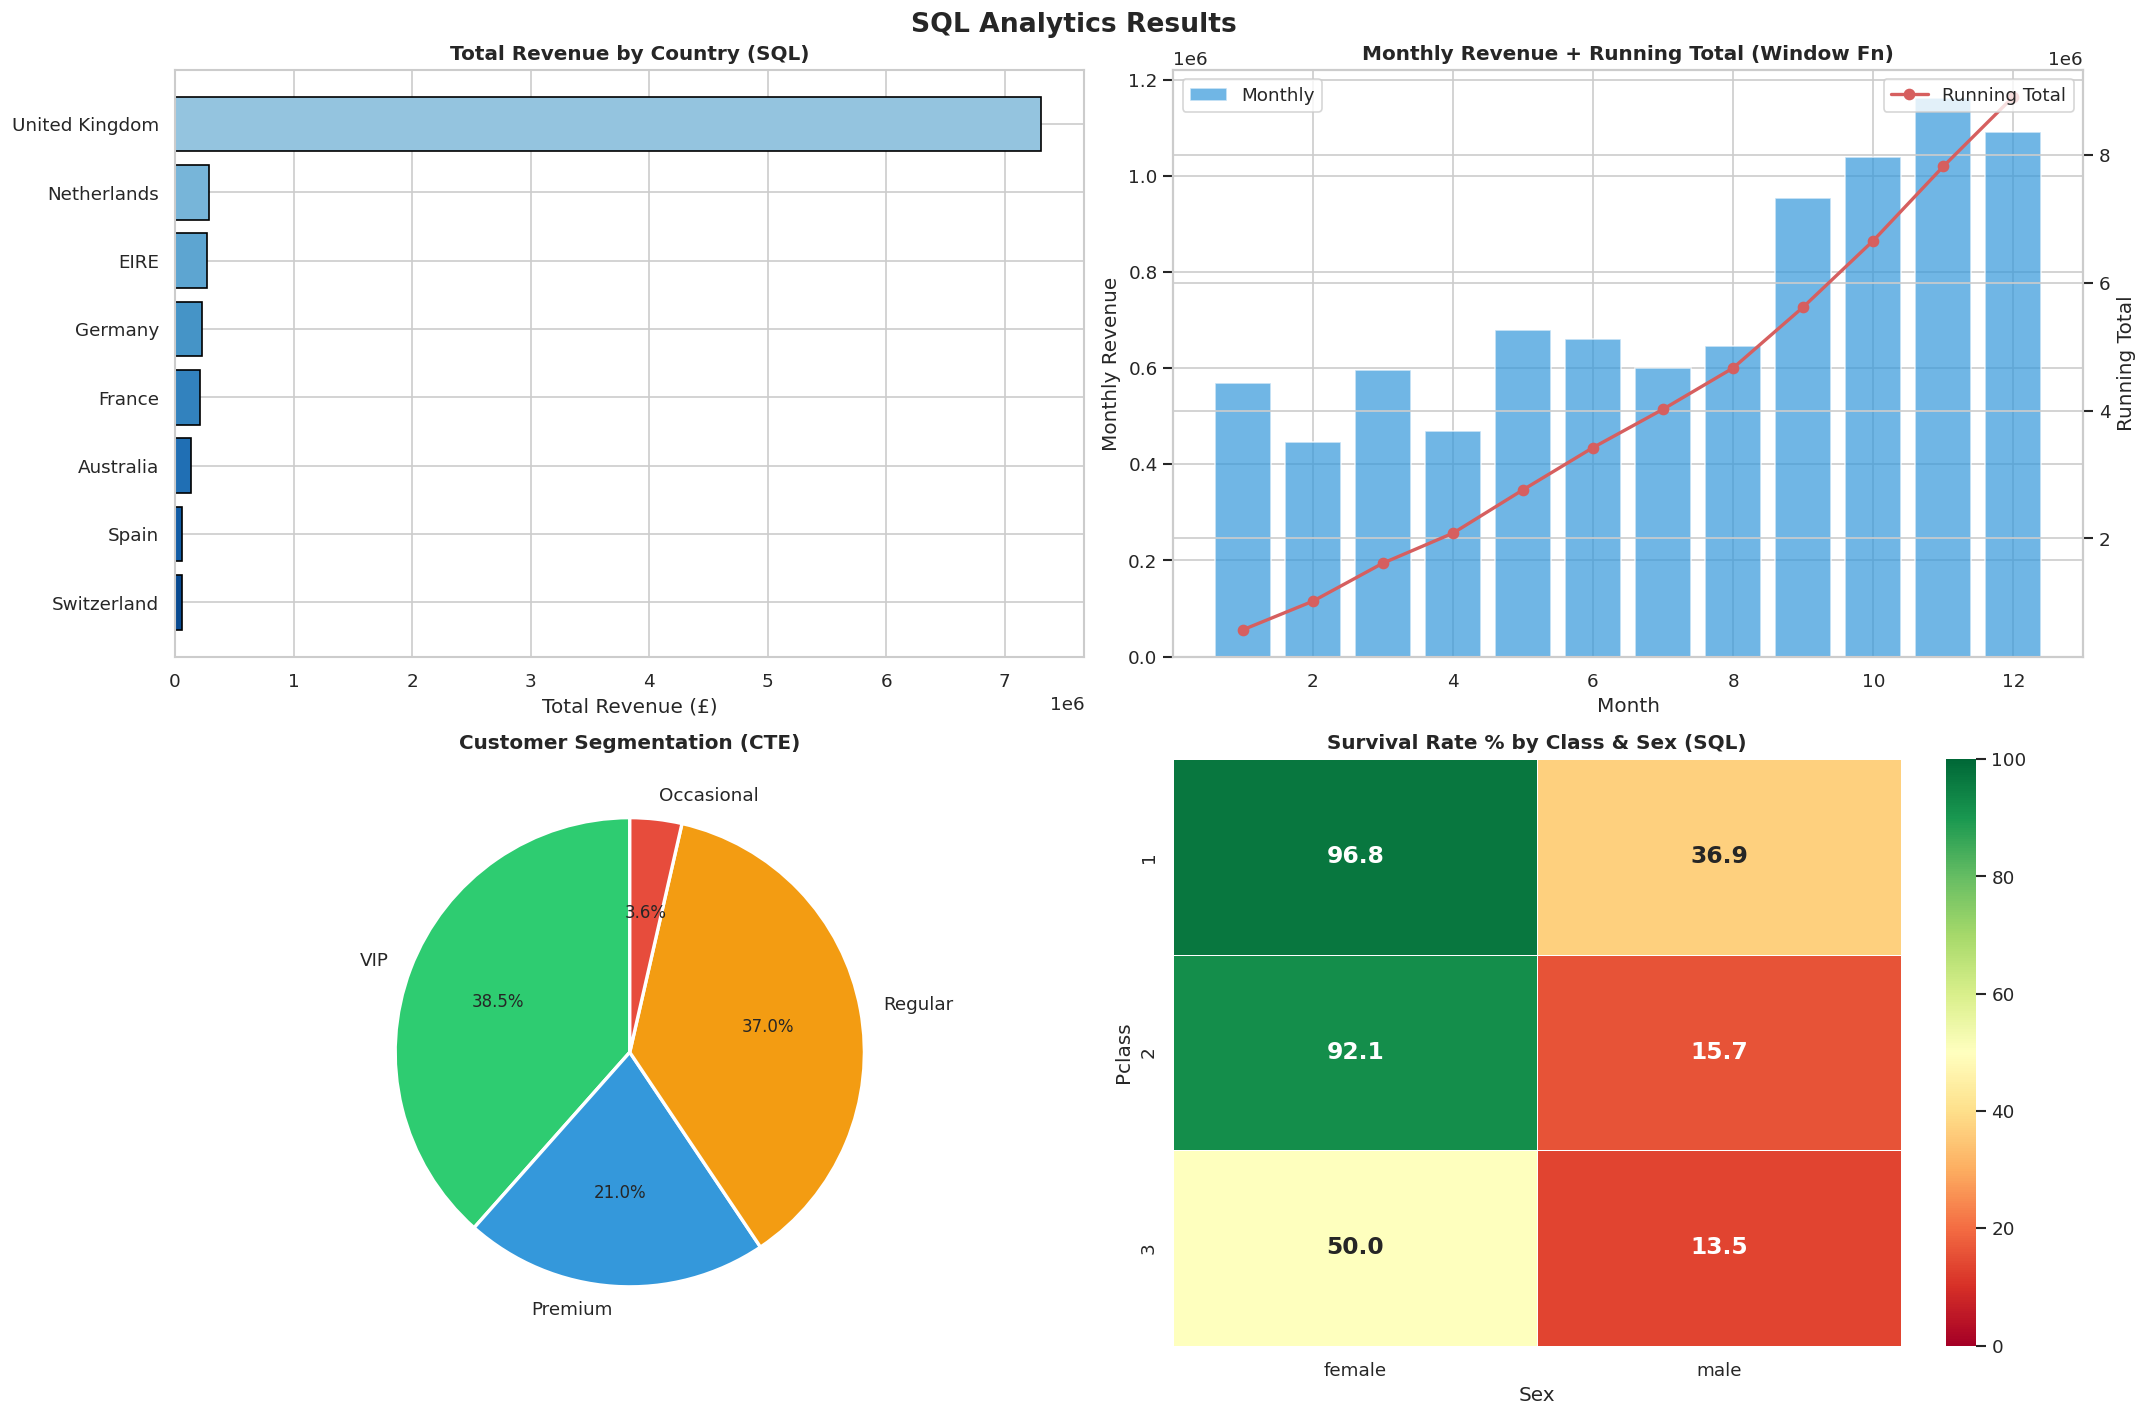

Plot saved: 05_sql_analytics.png


In [7]:
# Cell 5 - SQL Analytics (SQLite = full SQL in Colab)
print("=" * 60)
print("  SQL ANALYTICS ENGINE")
print("=" * 60)

class SQLAnalytics:

    def __init__(self):
        self.conn = sqlite3.connect(':memory:')
        self.cur  = self.conn.cursor()

    def load_tables(self, retail_df, titanic_df, wb_df):
        """Load DataFrames into SQLite"""
        retail_df.to_sql('retail',  self.conn,
                          if_exists='replace', index=False)
        titanic_df.to_sql('titanic', self.conn,
                           if_exists='replace', index=False)
        wb_df.to_sql('worldbank', self.conn,
                      if_exists='replace', index=False)
        print("  Tables created: retail, titanic, worldbank")

    def run_query(self, sql, label=''):
        """Execute SQL and return DataFrame"""
        t0     = time.time()
        result = pd.read_sql_query(sql, self.conn)
        elapsed = (time.time() - t0) * 1000
        if label:
            print(f"\n  [{label}] {elapsed:.2f}ms | "
                  f"{len(result)} rows")
        return result

    def run_all_queries(self):
        results = {}

        # 1. Revenue by Country
        results['revenue_country'] = self.run_query("""
            SELECT Country,
                   COUNT(*)          AS Transactions,
                   SUM(Revenue)      AS TotalRevenue,
                   AVG(Revenue)      AS AvgRevenue,
                   MAX(Revenue)      AS MaxRevenue
            FROM   retail
            GROUP  BY Country
            ORDER  BY TotalRevenue DESC
            LIMIT  10
        """, "Revenue by Country")

        # 2. Window Function - Running Total
        results['running_total'] = self.run_query("""
            SELECT Month,
                   SUM(Revenue)       AS MonthlyRevenue,
                   SUM(SUM(Revenue))
                     OVER (ORDER BY Month
                           ROWS BETWEEN UNBOUNDED PRECEDING
                                    AND CURRENT ROW)
                                      AS RunningTotal
            FROM   retail
            GROUP  BY Month
            ORDER  BY Month
        """, "Window Function - Running Total")

        # 3. CTE - Customer Segmentation
        results['customer_seg'] = self.run_query("""
            WITH CustomerRevenue AS (
                SELECT CustomerID,
                       COUNT(DISTINCT InvoiceNo) AS Orders,
                       SUM(Revenue)              AS TotalSpend,
                       AVG(Revenue)              AS AvgOrderValue
                FROM   retail
                GROUP  BY CustomerID
            ),
            CustomerSegment AS (
                SELECT *,
                       CASE
                         WHEN TotalSpend >= 1000 THEN 'VIP'
                         WHEN TotalSpend >= 500  THEN 'Premium'
                         WHEN TotalSpend >= 100  THEN 'Regular'
                         ELSE 'Occasional'
                       END AS Segment
                FROM CustomerRevenue
            )
            SELECT Segment,
                   COUNT(*)       AS Customers,
                   AVG(TotalSpend) AS AvgSpend,
                   SUM(TotalSpend) AS SegmentRevenue
            FROM   CustomerSegment
            GROUP  BY Segment
            ORDER  BY AvgSpend DESC
        """, "CTE - Customer Segmentation")

        # 4. Titanic - Survival Analysis
        results['survival'] = self.run_query("""
            SELECT Pclass,
                   Sex,
                   ROUND(AVG(Survived)*100, 2) AS SurvivalRate,
                   COUNT(*)                     AS Total,
                   SUM(Survived)                AS Survived,
                   ROUND(AVG(Age), 1)           AS AvgAge,
                   ROUND(AVG(Fare), 2)          AS AvgFare
            FROM   titanic
            GROUP  BY Pclass, Sex
            ORDER  BY Pclass, Sex
        """, "Titanic - Survival by Class & Sex")

        # 5. Rank function - Top products per country
        results['top_products'] = self.run_query("""
            SELECT *
            FROM (
                SELECT Country,
                       Description,
                       SUM(Revenue) AS Revenue,
                       RANK() OVER (PARTITION BY Country
                                    ORDER BY SUM(Revenue) DESC)
                                   AS CountryRank
                FROM   retail
                GROUP  BY Country, Description
            ) ranked
            WHERE CountryRank <= 3
            ORDER  BY Country, CountryRank
            LIMIT  30
        """, "RANK - Top 3 Products per Country")

        # 6. World Bank - GDP Growth Rate
        results['gdp_growth'] = self.run_query("""
            SELECT Country, Year, GDP_Billions,
                   LAG(GDP_Billions) OVER
                     (PARTITION BY Country ORDER BY Year)
                   AS PrevYearGDP,
                   ROUND(
                     (GDP_Billions -
                      LAG(GDP_Billions) OVER
                        (PARTITION BY Country ORDER BY Year))
                     / LAG(GDP_Billions) OVER
                        (PARTITION BY Country ORDER BY Year) * 100,
                   2) AS GrowthRate_Pct
            FROM   worldbank
            WHERE  Year >= 2015
            ORDER  BY Country, Year
            LIMIT  50
        """, "LAG - GDP Growth Rate by Country")

        return results

# Run SQL analytics
sql_engine = SQLAnalytics()
sql_engine.load_tables(retail_df, titanic_df, wb_df)
sql_results = sql_engine.run_all_queries()

# Print key results
print("\n  Revenue by Country (Top 5):")
print(sql_results['revenue_country'].head().to_string(index=False))

print("\n  Customer Segments:")
print(sql_results['customer_seg'].to_string(index=False))

print("\n  Titanic Survival by Class & Sex:")
print(sql_results['survival'].to_string(index=False))

# Plot SQL results
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('SQL Analytics Results', fontsize=16, fontweight='bold')

# Revenue by Country
rc = sql_results['revenue_country'].head(8)
axes[0,0].barh(rc['Country'], rc['TotalRevenue'],
               color=plt.cm.Blues(np.linspace(0.4,0.9,len(rc))),
               edgecolor='black')
axes[0,0].set_title('Total Revenue by Country (SQL)',
                    fontweight='bold')
axes[0,0].set_xlabel('Total Revenue (£)')
axes[0,0].invert_yaxis()

# Running Total
rt = sql_results['running_total']
axes[0,1].bar(rt['Month'], rt['MonthlyRevenue'],
              color='#3498db', alpha=0.7, label='Monthly')
ax_twin = axes[0,1].twinx()
ax_twin.plot(rt['Month'], rt['RunningTotal'],
             'r-o', linewidth=2, markersize=6, label='Running Total')
axes[0,1].set_title('Monthly Revenue + Running Total (Window Fn)',
                    fontweight='bold')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Monthly Revenue')
ax_twin.set_ylabel('Running Total')
axes[0,1].legend(loc='upper left')
ax_twin.legend(loc='upper right')

# Customer Segments
cs = sql_results['customer_seg']
axes[1,0].pie(cs['Customers'], labels=cs['Segment'],
              autopct='%1.1f%%',
              colors=['#2ecc71','#3498db','#f39c12','#e74c3c'],
              startangle=90,
              wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1,0].set_title('Customer Segmentation (CTE)',
                    fontweight='bold')

# Survival heatmap
sv = sql_results['survival']
sv_pivot = sv.pivot(index='Pclass', columns='Sex',
                    values='SurvivalRate')
sns.heatmap(sv_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[1,1], linewidths=0.5, vmin=0, vmax=100,
            annot_kws={'size':14,'weight':'bold'})
axes[1,1].set_title('Survival Rate % by Class & Sex (SQL)',
                    fontweight='bold')

plt.tight_layout()
plt.savefig('05_sql_analytics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: 05_sql_analytics.png")

  MACHINE LEARNING PIPELINE

[Titanic Survival Classification]
  Logistic Regression      : Acc=0.7933 CV=0.7978 Time=0.117s
  Random Forest            : Acc=0.8045 CV=0.7951 Time=0.436s
  Gradient Boosting        : Acc=0.8101 CV=0.8190 Time=0.419s

  Best Model: Gradient Boosting (0.8101)
  Feature Importances:
    Sex_enc             : 0.4679
    Fare                : 0.1618
    Pclass              : 0.1508
    Age                 : 0.1473
    FamilySize          : 0.0507
    Embarked_enc        : 0.0205
    IsAlone             : 0.0009

[RFM Analysis]
  RFM customers: 4338

[K-Means Customer Clustering]
  K-Means: 4 clusters, Silhouette=0.6162

  Cluster Summary:
         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1359.05
1         248.08       1.55     480.62
2           7.38      82.54  127338.31
3          15.50      22.33   12709.09

[Revenue Regression]
  Linear Regression: R²=0.5225, RMSE=53.0042


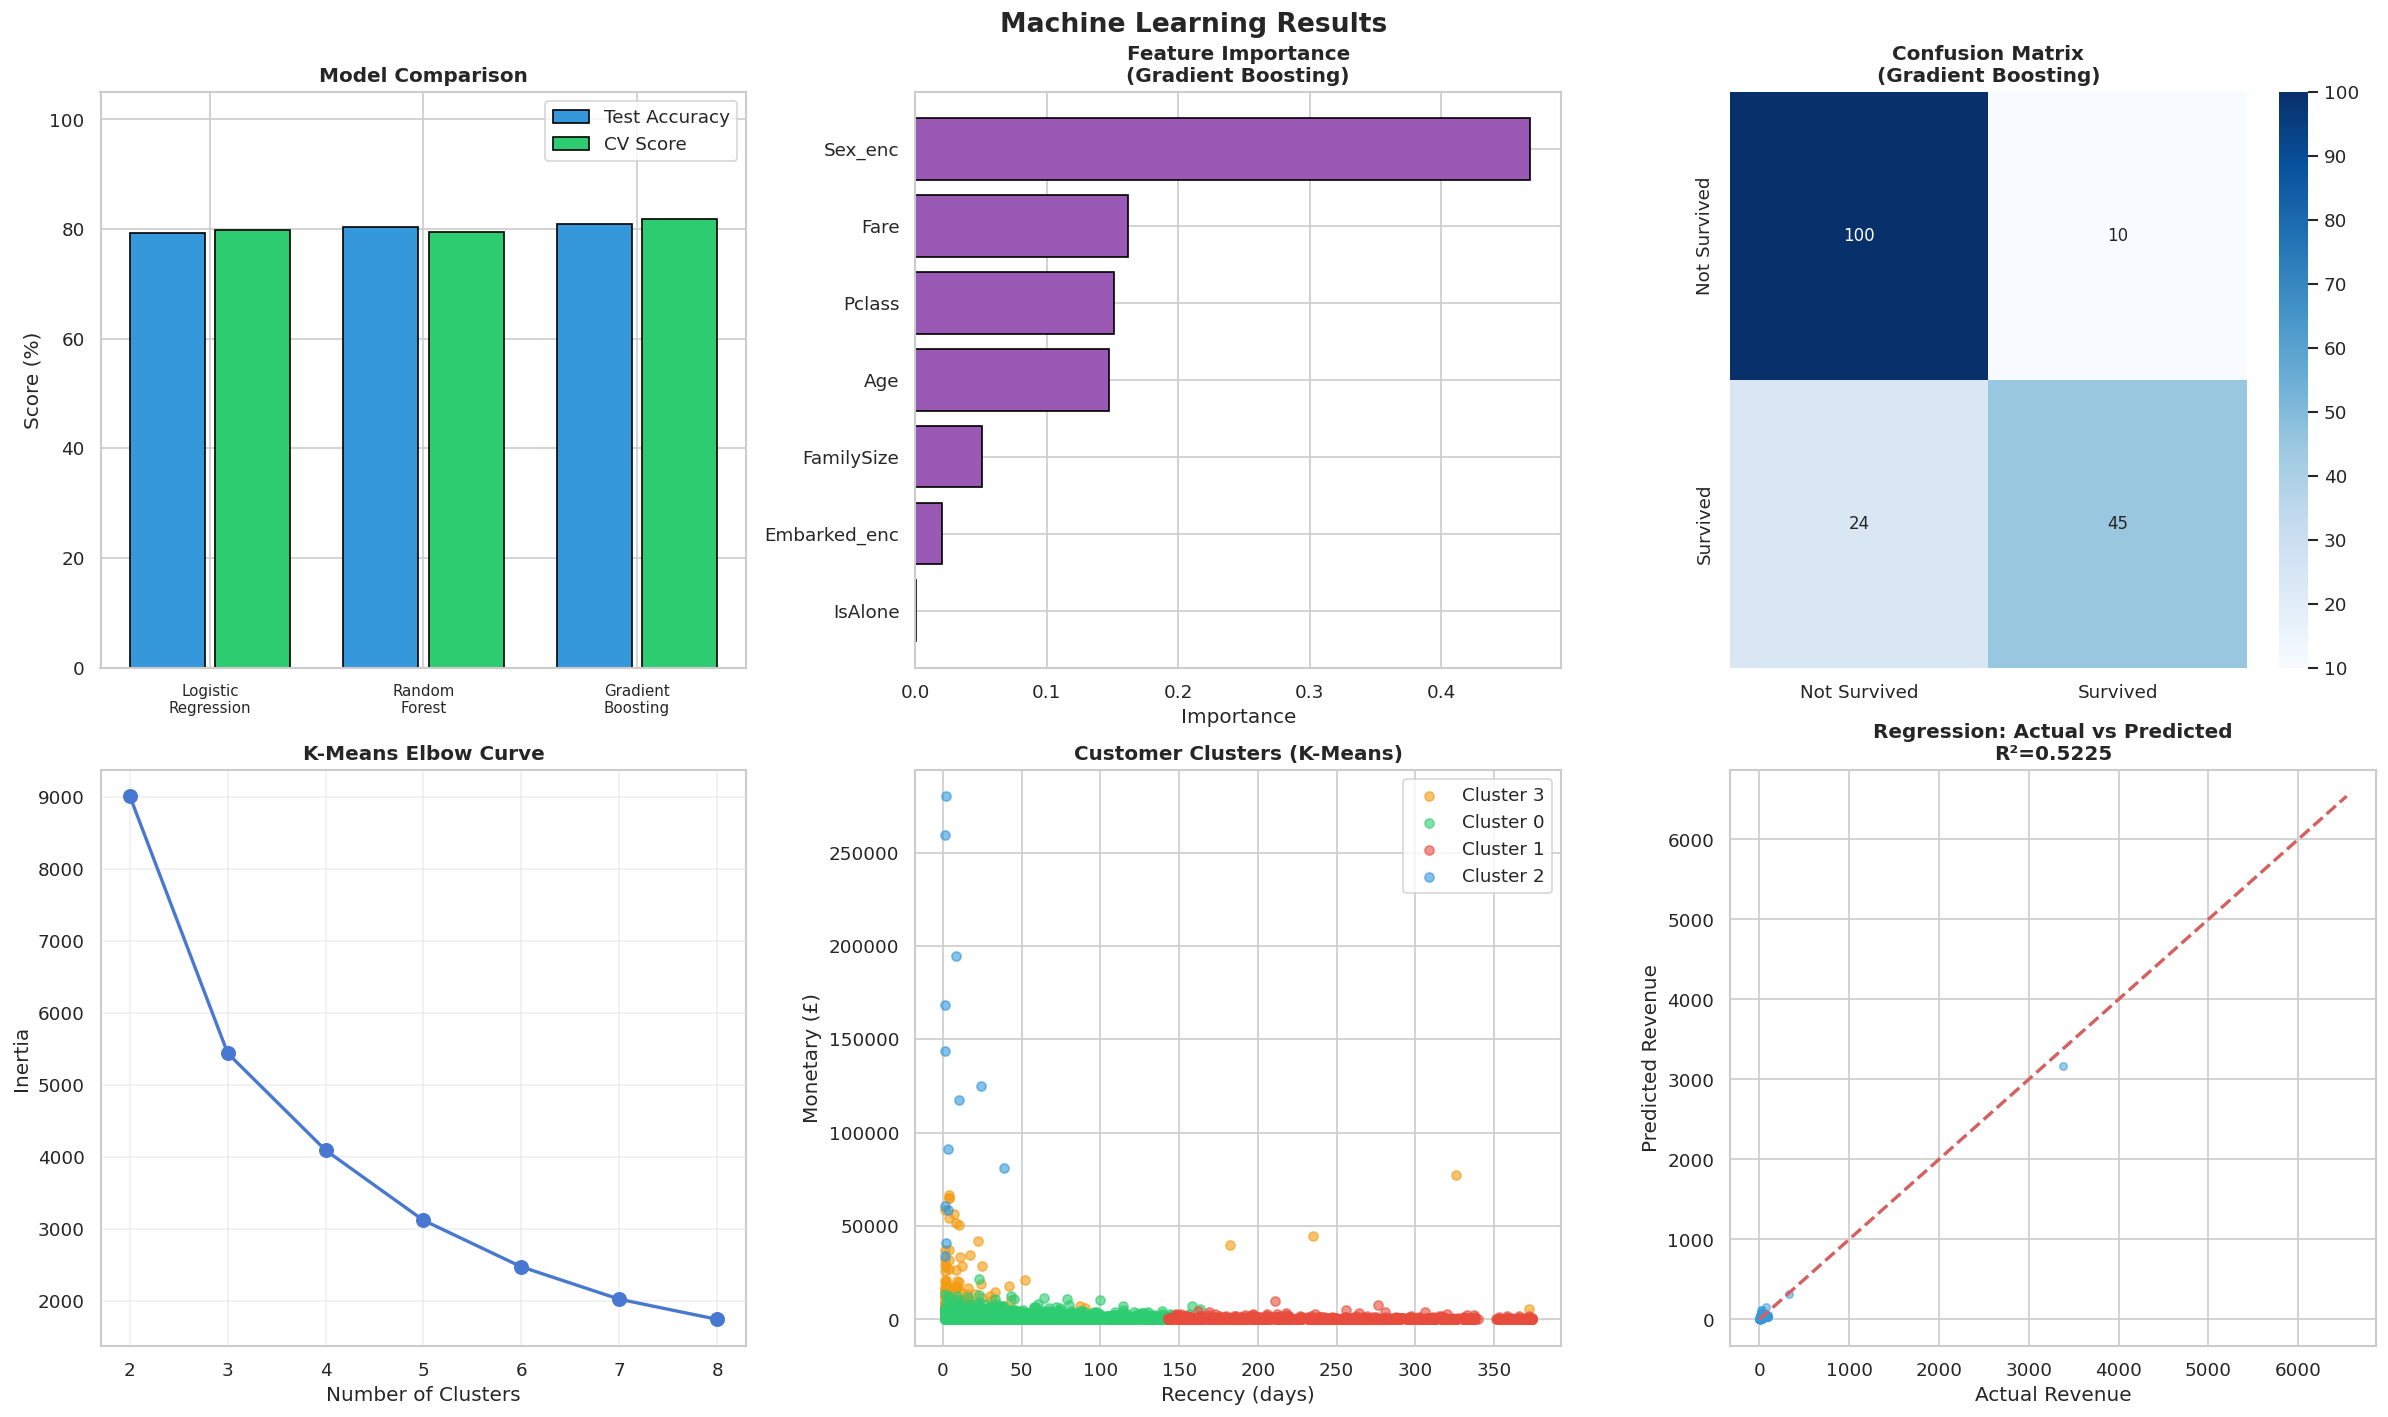


Plot saved: 07_ml_pipeline.png

Machine Learning Pipeline Completed Successfully!


In [11]:
# Cell 7 - Machine Learning Pipeline (FIXED)
print("=" * 60)
print("  MACHINE LEARNING PIPELINE")
print("=" * 60)

class MLPipeline:

    def prepare_titanic(self, df):
        """Prepare Titanic features"""
        le = LabelEncoder()
        df2 = df.copy()

        df2['Sex_enc'] = le.fit_transform(df2['Sex'].astype(str))
        df2['Embarked_enc'] = le.fit_transform(
            df2['Embarked'].astype(str)
        )

        features = [
            'Pclass', 'Sex_enc', 'Age', 'Fare',
            'FamilySize', 'IsAlone', 'Embarked_enc'
        ]

        X = df2[features].fillna(0)
        y = df2['Survived']

        return X, y, features

    def train_classifiers(self, X_train, X_test,
                          y_train, y_test):
        """Train and compare multiple classifiers"""

        models = {
            'Logistic Regression': LogisticRegression(
                max_iter=1000,
                random_state=42
            ),

            'Random Forest': RandomForestClassifier(
                n_estimators=100,
                random_state=42
            ),

            'Gradient Boosting': GradientBoostingClassifier(
                n_estimators=100,
                random_state=42
            )
        }

        results = {}

        for name, model in models.items():

            t0 = time.time()

            model.fit(X_train, y_train)

            train_time = time.time() - t0

            y_pred = model.predict(X_test)

            cv_score = cross_val_score(
                model,
                X_train,
                y_train,
                cv=5
            ).mean()

            results[name] = {
                'model': model,
                'accuracy': (y_pred == y_test).mean(),
                'cv_score': cv_score,
                'train_time': train_time,
                'predictions': y_pred
            }

            print(
                f"  {name:25s}: "
                f"Acc={results[name]['accuracy']:.4f} "
                f"CV={cv_score:.4f} "
                f"Time={train_time:.3f}s"
            )

        return results

    def feature_importance(self, model, features):

        if hasattr(model, 'feature_importances_'):
            return dict(zip(features, model.feature_importances_))

        return {}

    def kmeans_clustering(self, df, n_clusters=4):
        """K-Means customer clustering"""

        required_cols = ['Recency', 'Frequency', 'Monetary']

        if not all(c in df.columns for c in required_cols):
            print("  RFM columns missing.")
            return df, None, None

        X = df[required_cols].fillna(0)

        sc = StandardScaler()

        X_sc = sc.fit_transform(X)

        # Elbow Method
        inertias = []

        k_range = range(2, 9)

        for k in k_range:

            km = KMeans(
                n_clusters=k,
                random_state=42,
                n_init=10
            )

            km.fit(X_sc)

            inertias.append(km.inertia_)

        # Final Model
        km_final = KMeans(
            n_clusters=n_clusters,
            random_state=42,
            n_init=10
        )

        df = df.copy()

        df['Cluster'] = km_final.fit_predict(X_sc)

        silhouette = silhouette_score(
            X_sc,
            df['Cluster']
        )

        print(
            f"  K-Means: {n_clusters} clusters, "
            f"Silhouette={silhouette:.4f}"
        )

        return df, inertias, k_range

    def regression_analysis(self, df):
        """Linear Regression - Revenue Prediction"""

        required_cols = ['Quantity', 'UnitPrice', 'Revenue']

        if not all(c in df.columns for c in required_cols):
            print("  Revenue columns missing.")
            return None, None

        X = df[['Quantity', 'UnitPrice']].fillna(0)

        y = df['Revenue'].fillna(0)

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42
        )

        lr = LinearRegression()

        lr.fit(X_train, y_train)

        y_pred = lr.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)

        r2 = r2_score(y_test, y_pred)

        print(
            f"  Linear Regression: "
            f"R²={r2:.4f}, "
            f"RMSE={np.sqrt(mse):.4f}"
        )

        return lr, (y_test, y_pred, r2, mse)


# ============================================================
# FIXED RFM ANALYSIS FUNCTION
# ============================================================

def fixed_rfm_analysis(retail_df):

    print("\n[RFM Analysis]")

    try:

        df = retail_df.copy()

        # Ensure InvoiceDate is datetime
        df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

        # Remove missing CustomerID
        df = df.dropna(subset=['CustomerID'])

        # Create Revenue if missing
        if 'Revenue' not in df.columns:
            df['Revenue'] = df['Quantity'] * df['UnitPrice']

        # Reference date
        snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

        # RFM Table
        rfm = df.groupby('CustomerID').agg({
            'InvoiceDate': lambda x:
                (snapshot_date - x.max()).days,
            'InvoiceNo': 'nunique',
            'Revenue': 'sum'
        }).reset_index()

        rfm.columns = [
            'CustomerID',
            'Recency',
            'Frequency',
            'Monetary'
        ]

        # Remove duplicate edges issue
        rfm['R_Score'] = pd.qcut(
            rfm['Recency'],
            q=4,
            labels=[4, 3, 2, 1],
            duplicates='drop'
        )

        rfm['F_Score'] = pd.qcut(
            rfm['Frequency'].rank(method='first'),
            q=4,
            labels=[1, 2, 3, 4],
            duplicates='drop'
        )

        rfm['M_Score'] = pd.qcut(
            rfm['Monetary'].rank(method='first'),
            q=4,
            labels=[1, 2, 3, 4],
            duplicates='drop'
        )

        rfm['RFM_Score'] = (
            rfm['R_Score'].astype(str) +
            rfm['F_Score'].astype(str) +
            rfm['M_Score'].astype(str)
        )

        print(f"  RFM customers: {len(rfm)}")

        return rfm

    except Exception as e:

        print(f"  RFM Analysis Error: {e}")

        return pd.DataFrame()


# ============================================================
# RUN ML PIPELINE
# ============================================================

ml = MLPipeline()

# ------------------------------------------------------------
# TITANIC CLASSIFICATION
# ------------------------------------------------------------

print("\n[Titanic Survival Classification]")

X, y, features = ml.prepare_titanic(titanic_df)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

ml_results = ml.train_classifiers(
    X_train,
    X_test,
    y_train,
    y_test
)

# ------------------------------------------------------------
# FEATURE IMPORTANCE
# ------------------------------------------------------------

best_model_name = max(
    ml_results,
    key=lambda x: ml_results[x]['accuracy']
)

best_model = ml_results[best_model_name]['model']

feat_imp = ml.feature_importance(
    best_model,
    features
)

print(
    f"\n  Best Model: {best_model_name} "
    f"({ml_results[best_model_name]['accuracy']:.4f})"
)

if feat_imp:

    print("  Feature Importances:")

    for f, i in sorted(
        feat_imp.items(),
        key=lambda x: x[1],
        reverse=True
    ):

        print(f"    {f:20s}: {i:.4f}")

# ------------------------------------------------------------
# FIXED RFM ANALYSIS
# ------------------------------------------------------------

rfm_df = fixed_rfm_analysis(retail_df)

# ------------------------------------------------------------
# K-MEANS CLUSTERING
# ------------------------------------------------------------

print("\n[K-Means Customer Clustering]")

rfm_cluster = pd.DataFrame()

inertias = None
k_range = None

if len(rfm_df):

    rfm_cluster, inertias, k_range = ml.kmeans_clustering(
        rfm_df,
        n_clusters=4
    )

    if len(rfm_cluster):

        print("\n  Cluster Summary:")

        print(
            rfm_cluster.groupby('Cluster')
            [['Recency', 'Frequency', 'Monetary']]
            .mean()
            .round(2)
            .to_string()
        )

# ------------------------------------------------------------
# REGRESSION
# ------------------------------------------------------------

print("\n[Revenue Regression]")

lr_model, reg_results = ml.regression_analysis(retail_df)

# ============================================================
# VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

fig.suptitle(
    'Machine Learning Results',
    fontsize=16,
    fontweight='bold'
)

# ------------------------------------------------------------
# MODEL COMPARISON
# ------------------------------------------------------------

model_names = list(ml_results.keys())

accuracies = [
    ml_results[n]['accuracy']
    for n in model_names
]

cv_scores = [
    ml_results[n]['cv_score']
    for n in model_names
]

x_m = np.arange(len(model_names))

axes[0,0].bar(
    x_m - 0.2,
    [a * 100 for a in accuracies],
    0.35,
    label='Test Accuracy',
    color='#3498db',
    edgecolor='black'
)

axes[0,0].bar(
    x_m + 0.2,
    [c * 100 for c in cv_scores],
    0.35,
    label='CV Score',
    color='#2ecc71',
    edgecolor='black'
)

axes[0,0].set_xticks(x_m)

axes[0,0].set_xticklabels(
    [n.replace(' ', '\n') for n in model_names],
    fontsize=9
)

axes[0,0].set_title(
    'Model Comparison',
    fontweight='bold'
)

axes[0,0].set_ylabel('Score (%)')

axes[0,0].legend()

axes[0,0].set_ylim(0, 105)

# ------------------------------------------------------------
# FEATURE IMPORTANCE
# ------------------------------------------------------------

if feat_imp:

    sorted_fi = sorted(
        feat_imp.items(),
        key=lambda x: x[1],
        reverse=True
    )

    fi_names, fi_vals = zip(*sorted_fi)

    axes[0,1].barh(
        fi_names,
        fi_vals,
        color='#9b59b6',
        edgecolor='black'
    )

    axes[0,1].set_title(
        f'Feature Importance\n({best_model_name})',
        fontweight='bold'
    )

    axes[0,1].set_xlabel('Importance')

    axes[0,1].invert_yaxis()

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

from sklearn.metrics import confusion_matrix

best_preds = ml_results[best_model_name]['predictions']

cm = confusion_matrix(y_test, best_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0,2],
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

axes[0,2].set_title(
    f'Confusion Matrix\n({best_model_name})',
    fontweight='bold'
)

# ------------------------------------------------------------
# ELBOW CURVE
# ------------------------------------------------------------

if inertias is not None:

    axes[1,0].plot(
        list(k_range),
        inertias,
        'b-o',
        linewidth=2,
        markersize=8
    )

    axes[1,0].set_title(
        'K-Means Elbow Curve',
        fontweight='bold'
    )

    axes[1,0].set_xlabel('Number of Clusters')

    axes[1,0].set_ylabel('Inertia')

    axes[1,0].grid(True, alpha=0.3)

# ------------------------------------------------------------
# CLUSTER SCATTER
# ------------------------------------------------------------

if len(rfm_cluster):

    colors_c = [
        '#2ecc71',
        '#e74c3c',
        '#3498db',
        '#f39c12'
    ]

    for c in rfm_cluster['Cluster'].unique():

        mask = rfm_cluster['Cluster'] == c

        axes[1,1].scatter(
            rfm_cluster[mask]['Recency'],
            rfm_cluster[mask]['Monetary'],
            c=colors_c[int(c) % len(colors_c)],
            label=f'Cluster {c}',
            alpha=0.6,
            s=30
        )

    axes[1,1].set_title(
        'Customer Clusters (K-Means)',
        fontweight='bold'
    )

    axes[1,1].set_xlabel('Recency (days)')

    axes[1,1].set_ylabel('Monetary (£)')

    axes[1,1].legend()

# ------------------------------------------------------------
# REGRESSION PLOT
# ------------------------------------------------------------

if reg_results:

    y_test_r, y_pred_r, r2, mse = reg_results

    sample = min(200, len(y_test_r))

    axes[1,2].scatter(
        y_test_r[:sample],
        y_pred_r[:sample],
        alpha=0.5,
        color='#3498db',
        s=20
    )

    max_val = max(
        y_test_r.max(),
        y_pred_r.max()
    )

    axes[1,2].plot(
        [0, max_val],
        [0, max_val],
        'r--',
        linewidth=2
    )

    axes[1,2].set_title(
        f'Regression: Actual vs Predicted\nR²={r2:.4f}',
        fontweight='bold'
    )

    axes[1,2].set_xlabel('Actual Revenue')

    axes[1,2].set_ylabel('Predicted Revenue')

# ------------------------------------------------------------
# FINALIZE
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    '07_ml_pipeline.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("\nPlot saved: 07_ml_pipeline.png")
print("\nMachine Learning Pipeline Completed Successfully!")

  FINANCIAL & WORLD BANK ANALYTICS
  Stock Return Correlations:
        AAPL  GOOGL   MSFT   AMZN   META
AAPL   1.000  0.704  0.741  0.622  0.575
GOOGL  0.704  1.000  0.730  0.681  0.656
MSFT   0.741  0.730  1.000  0.690  0.599
AMZN   0.622  0.681  0.690  1.000  0.603
META   0.575  0.656  0.599  0.603  1.000

  Top GDP Countries (2023):
                  Country  GDP_Billions
                    World     105435.04
              High income      67653.74
             OECD members      64098.87
Post-demographic dividend      59851.80
         IDA & IBRD total      41559.72
                IBRD only      38733.04
      Low & middle income      37425.21
            Middle income      36786.94
      East Asia & Pacific      30775.66
            North America      29509.30


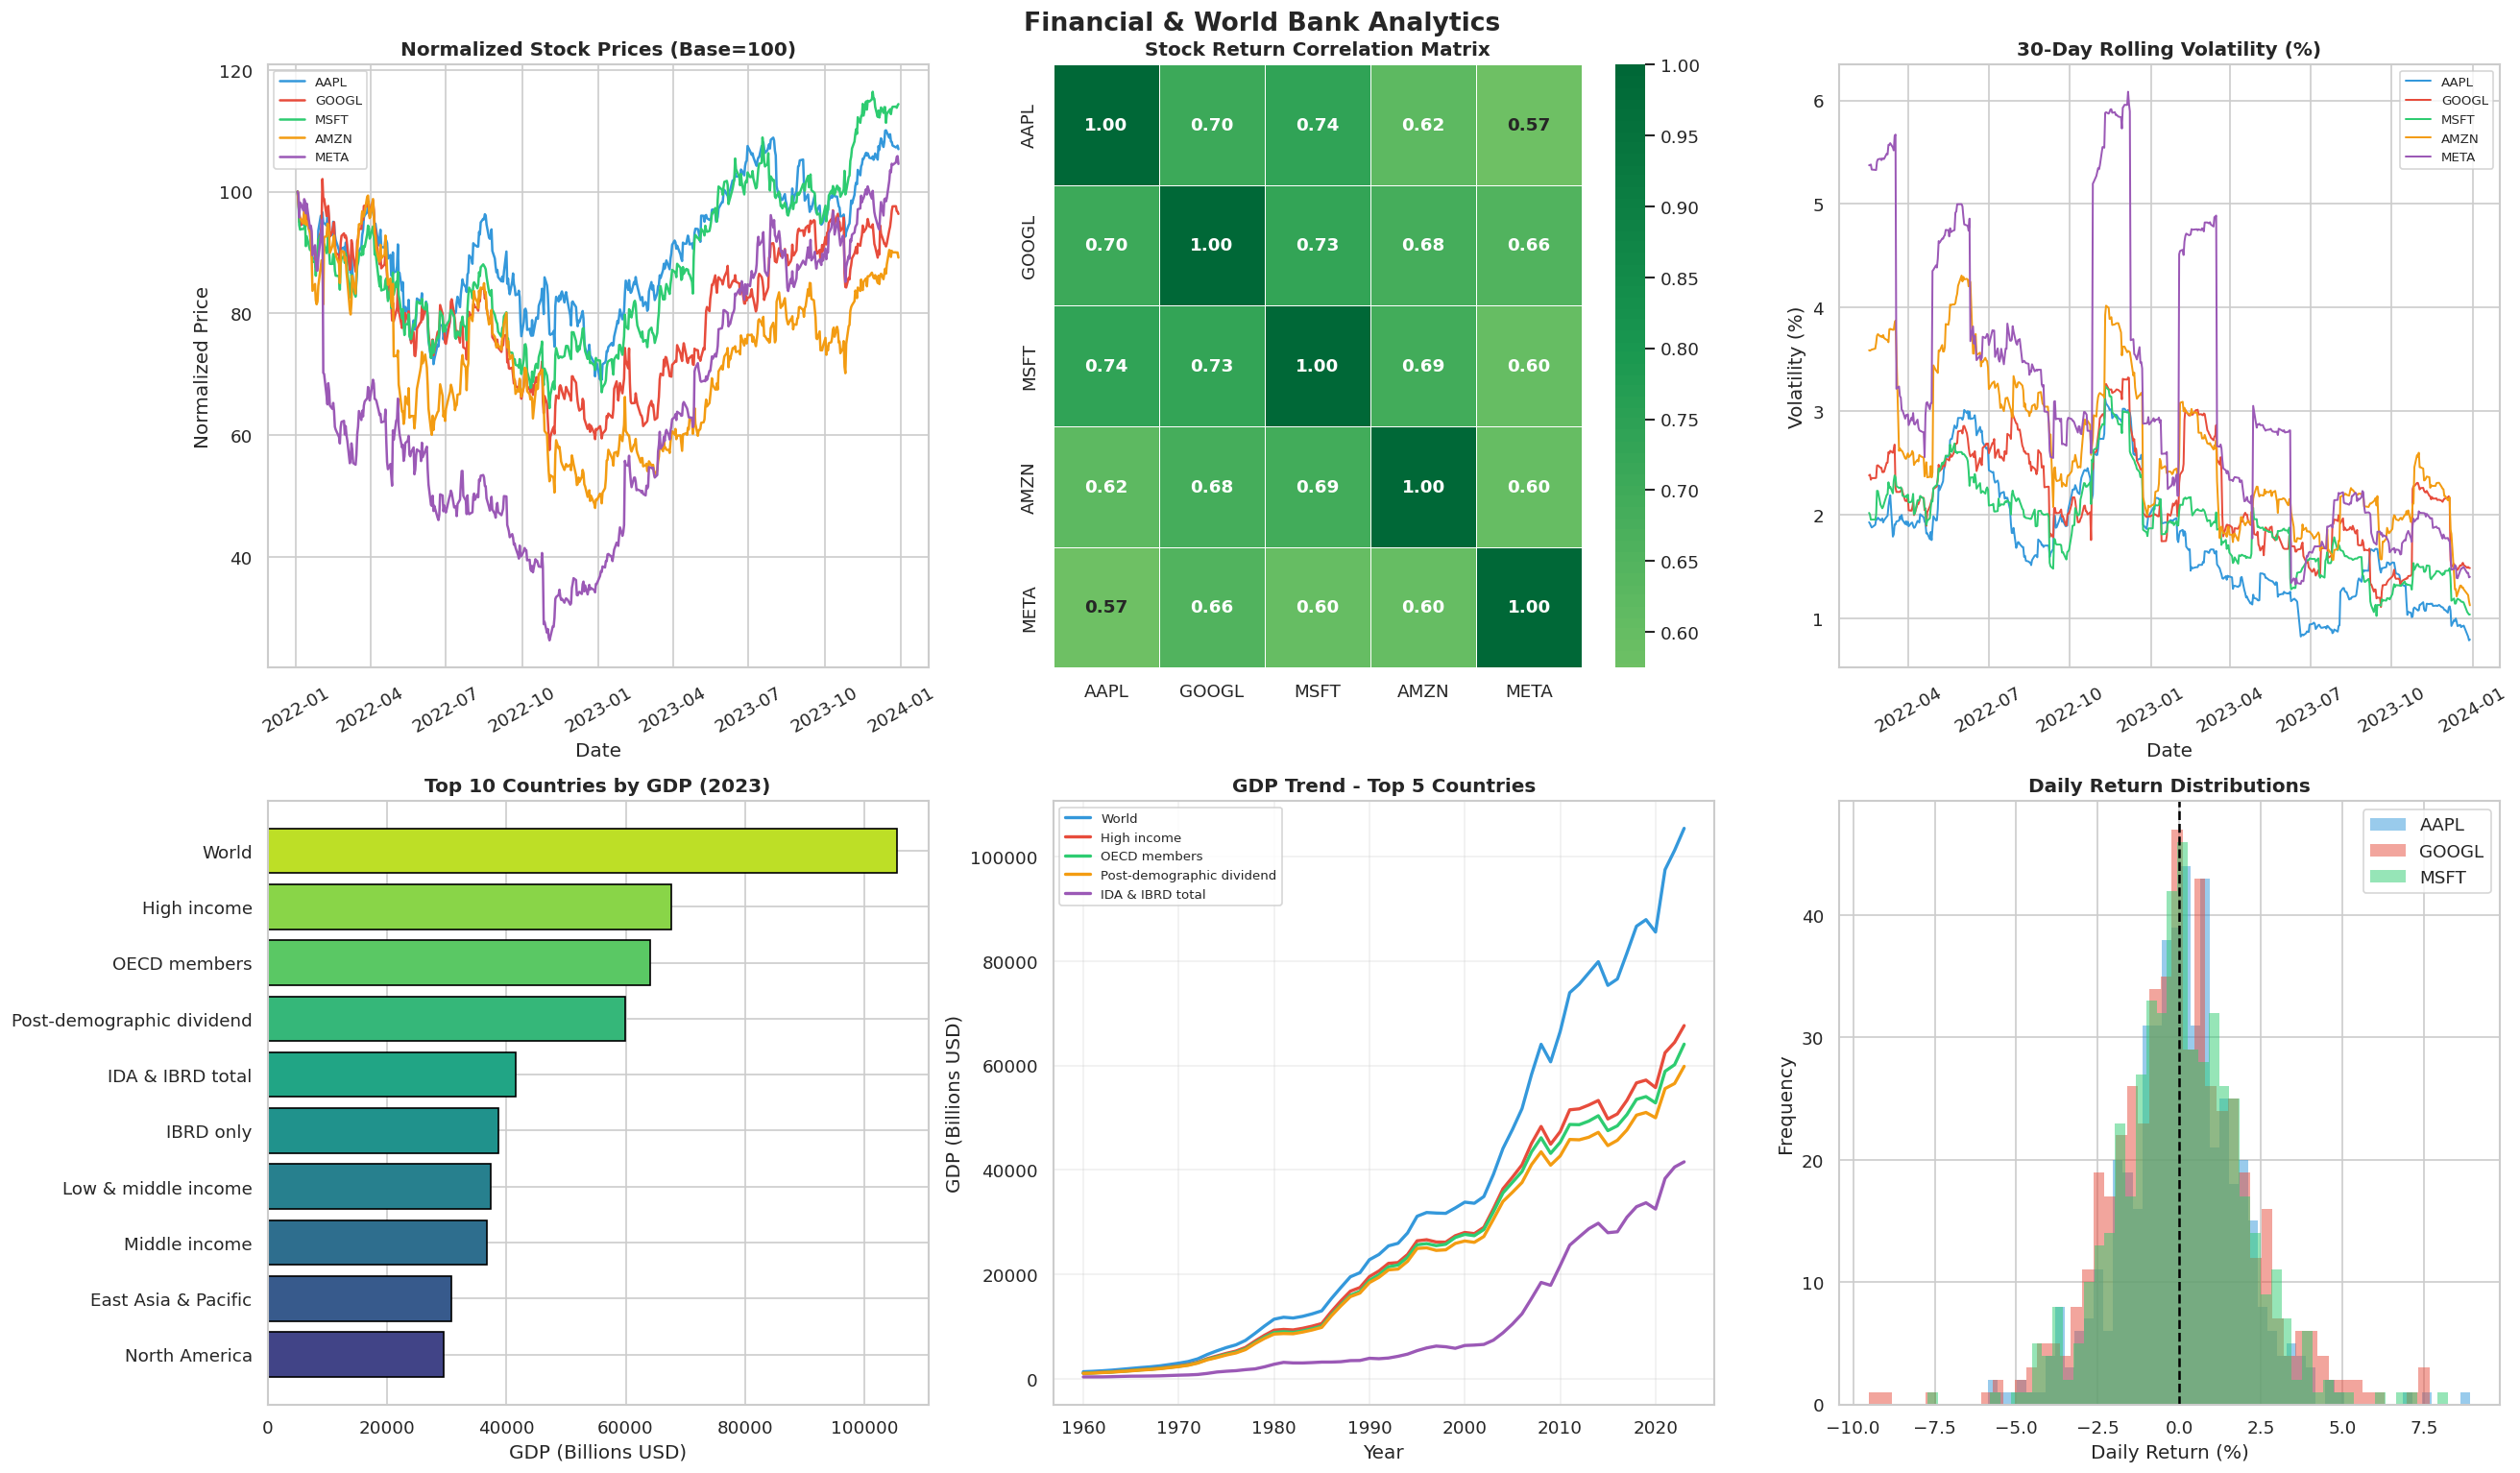

Plot saved: 08_financial_analytics.png


In [12]:
# Cell 8 - Financial & World Bank Analytics
print("=" * 60)
print("  FINANCIAL & WORLD BANK ANALYTICS")
print("=" * 60)

# ── Stock Analysis ────────────────────────────────────────────
tickers = ['AAPL','GOOGL','MSFT','AMZN','META']

# Daily returns
stock_returns = stock_df.copy()
for t in tickers:
    if t in stock_returns.columns:
        stock_returns[f'{t}_Return'] = (
            stock_returns[t].pct_change() * 100)

# Volatility (30-day rolling std)
for t in tickers:
    if t in stock_df.columns:
        stock_returns[f'{t}_Vol30'] = (
            stock_returns[f'{t}_Return']
            .rolling(30).std())

# Correlation matrix of returns
ret_cols = [f'{t}_Return' for t in tickers
            if f'{t}_Return' in stock_returns.columns]
ret_corr = stock_returns[ret_cols].corr()
ret_corr.index   = [c.replace('_Return','') for c in ret_corr.index]
ret_corr.columns = [c.replace('_Return','') for c in ret_corr.columns]

print("  Stock Return Correlations:")
print(ret_corr.round(3).to_string())

# Normalized prices (base=100)
stock_norm = stock_df.copy()
for t in tickers:
    if t in stock_norm.columns:
        stock_norm[f'{t}_Norm'] = (
            stock_norm[t] / stock_norm[t].iloc[0] * 100)

# ── World Bank Analysis ───────────────────────────────────────
# Top countries by latest GDP
col_gdp = 'GDP_Billions' if 'GDP_Billions' in wb_df.columns else 'GDP'
latest_year = wb_df['Year'].max()
latest_gdp  = (wb_df[wb_df['Year'] == latest_year]
               .nlargest(10, col_gdp))

# GDP growth trend for top 5
top5_countries = latest_gdp['Country'].head(5).tolist()
wb_top5        = wb_df[wb_df['Country'].isin(top5_countries)]

print(f"\n  Top GDP Countries ({latest_year}):")
print(latest_gdp[['Country', col_gdp]].to_string(index=False))

# ── Visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle('Financial & World Bank Analytics',
             fontsize=16, fontweight='bold')

# 1. Normalized stock prices
norm_cols = [f'{t}_Norm' for t in tickers
             if f'{t}_Norm' in stock_norm.columns]
colors_s = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']
for col, color in zip(norm_cols, colors_s):
    axes[0,0].plot(stock_norm['Date'],
                   stock_norm[col],
                   label=col.replace('_Norm',''),
                   color=color, linewidth=1.5)
axes[0,0].set_title('Normalized Stock Prices (Base=100)',
                    fontweight='bold')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Normalized Price')
axes[0,0].legend(fontsize=8)
axes[0,0].tick_params(axis='x', rotation=30)

# 2. Return correlation heatmap
sns.heatmap(ret_corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            ax=axes[0,1], linewidths=0.5,
            annot_kws={'size':11,'weight':'bold'})
axes[0,1].set_title('Stock Return Correlation Matrix',
                    fontweight='bold')

# 3. 30-day volatility
vol_cols = [f'{t}_Vol30' for t in tickers
            if f'{t}_Vol30' in stock_returns.columns]
for col, color in zip(vol_cols, colors_s):
    axes[0,2].plot(stock_returns['Date'],
                   stock_returns[col],
                   label=col.replace('_Vol30',''),
                   color=color, linewidth=1.2)
axes[0,2].set_title('30-Day Rolling Volatility (%)',
                    fontweight='bold')
axes[0,2].set_xlabel('Date')
axes[0,2].set_ylabel('Volatility (%)')
axes[0,2].legend(fontsize=8)
axes[0,2].tick_params(axis='x', rotation=30)

# 4. GDP by country (latest year)
gdp_sorted = latest_gdp.sort_values(col_gdp, ascending=True)
axes[1,0].barh(gdp_sorted['Country'], gdp_sorted[col_gdp],
               color=plt.cm.viridis(
                   np.linspace(0.2, 0.9, len(gdp_sorted))),
               edgecolor='black')
axes[1,0].set_title(f'Top 10 Countries by GDP ({latest_year})',
                    fontweight='bold')
axes[1,0].set_xlabel('GDP (Billions USD)')

# 5. GDP trend for top 5
palette_wb = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']
for country, color in zip(top5_countries, palette_wb):
    sub = wb_top5[wb_top5['Country']==country].sort_values('Year')
    if len(sub):
        axes[1,1].plot(sub['Year'], sub[col_gdp],
                       label=country, color=color, linewidth=2)
axes[1,1].set_title('GDP Trend - Top 5 Countries',
                    fontweight='bold')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('GDP (Billions USD)')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3)

# 6. Return distribution
if len(ret_cols) > 0:
    for col, color in zip(ret_cols[:3], colors_s[:3]):
        data = stock_returns[col].dropna()
        axes[1,2].hist(data, bins=50, alpha=0.5,
                       color=color, edgecolor='none',
                       label=col.replace('_Return',''))
    axes[1,2].axvline(0, color='black',
                      linestyle='--', linewidth=1.5)
    axes[1,2].set_title('Daily Return Distributions',
                        fontweight='bold')
    axes[1,2].set_xlabel('Daily Return (%)')
    axes[1,2].set_ylabel('Frequency')
    axes[1,2].legend()

plt.tight_layout()
plt.savefig('08_financial_analytics.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Plot saved: 08_financial_analytics.png")

  STATISTICAL ANALYSIS (R-EQUIVALENT)

[OLS Regression - Titanic Fare ~ Age + Pclass + Sex]
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        104.2519      6.548     15.922      0.000      91.401     117.103
Age           -0.1315      0.112     -1.177      0.240      -0.351       0.088
Pclass       -33.8283      1.709    -19.792      0.000     -37.183     -30.474
Sex_bin       -5.9559      2.871     -2.074      0.038     -11.591      -0.321
FamilySize     7.2293      0.862      8.386      0.000       5.537       8.921

[Logistic Regression - Survival ~ All Features]
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.7753      0.610      9.473      0.000       4.580       6.970
Age           -0.0381      0.008     -4.814      0.000      -0.054   

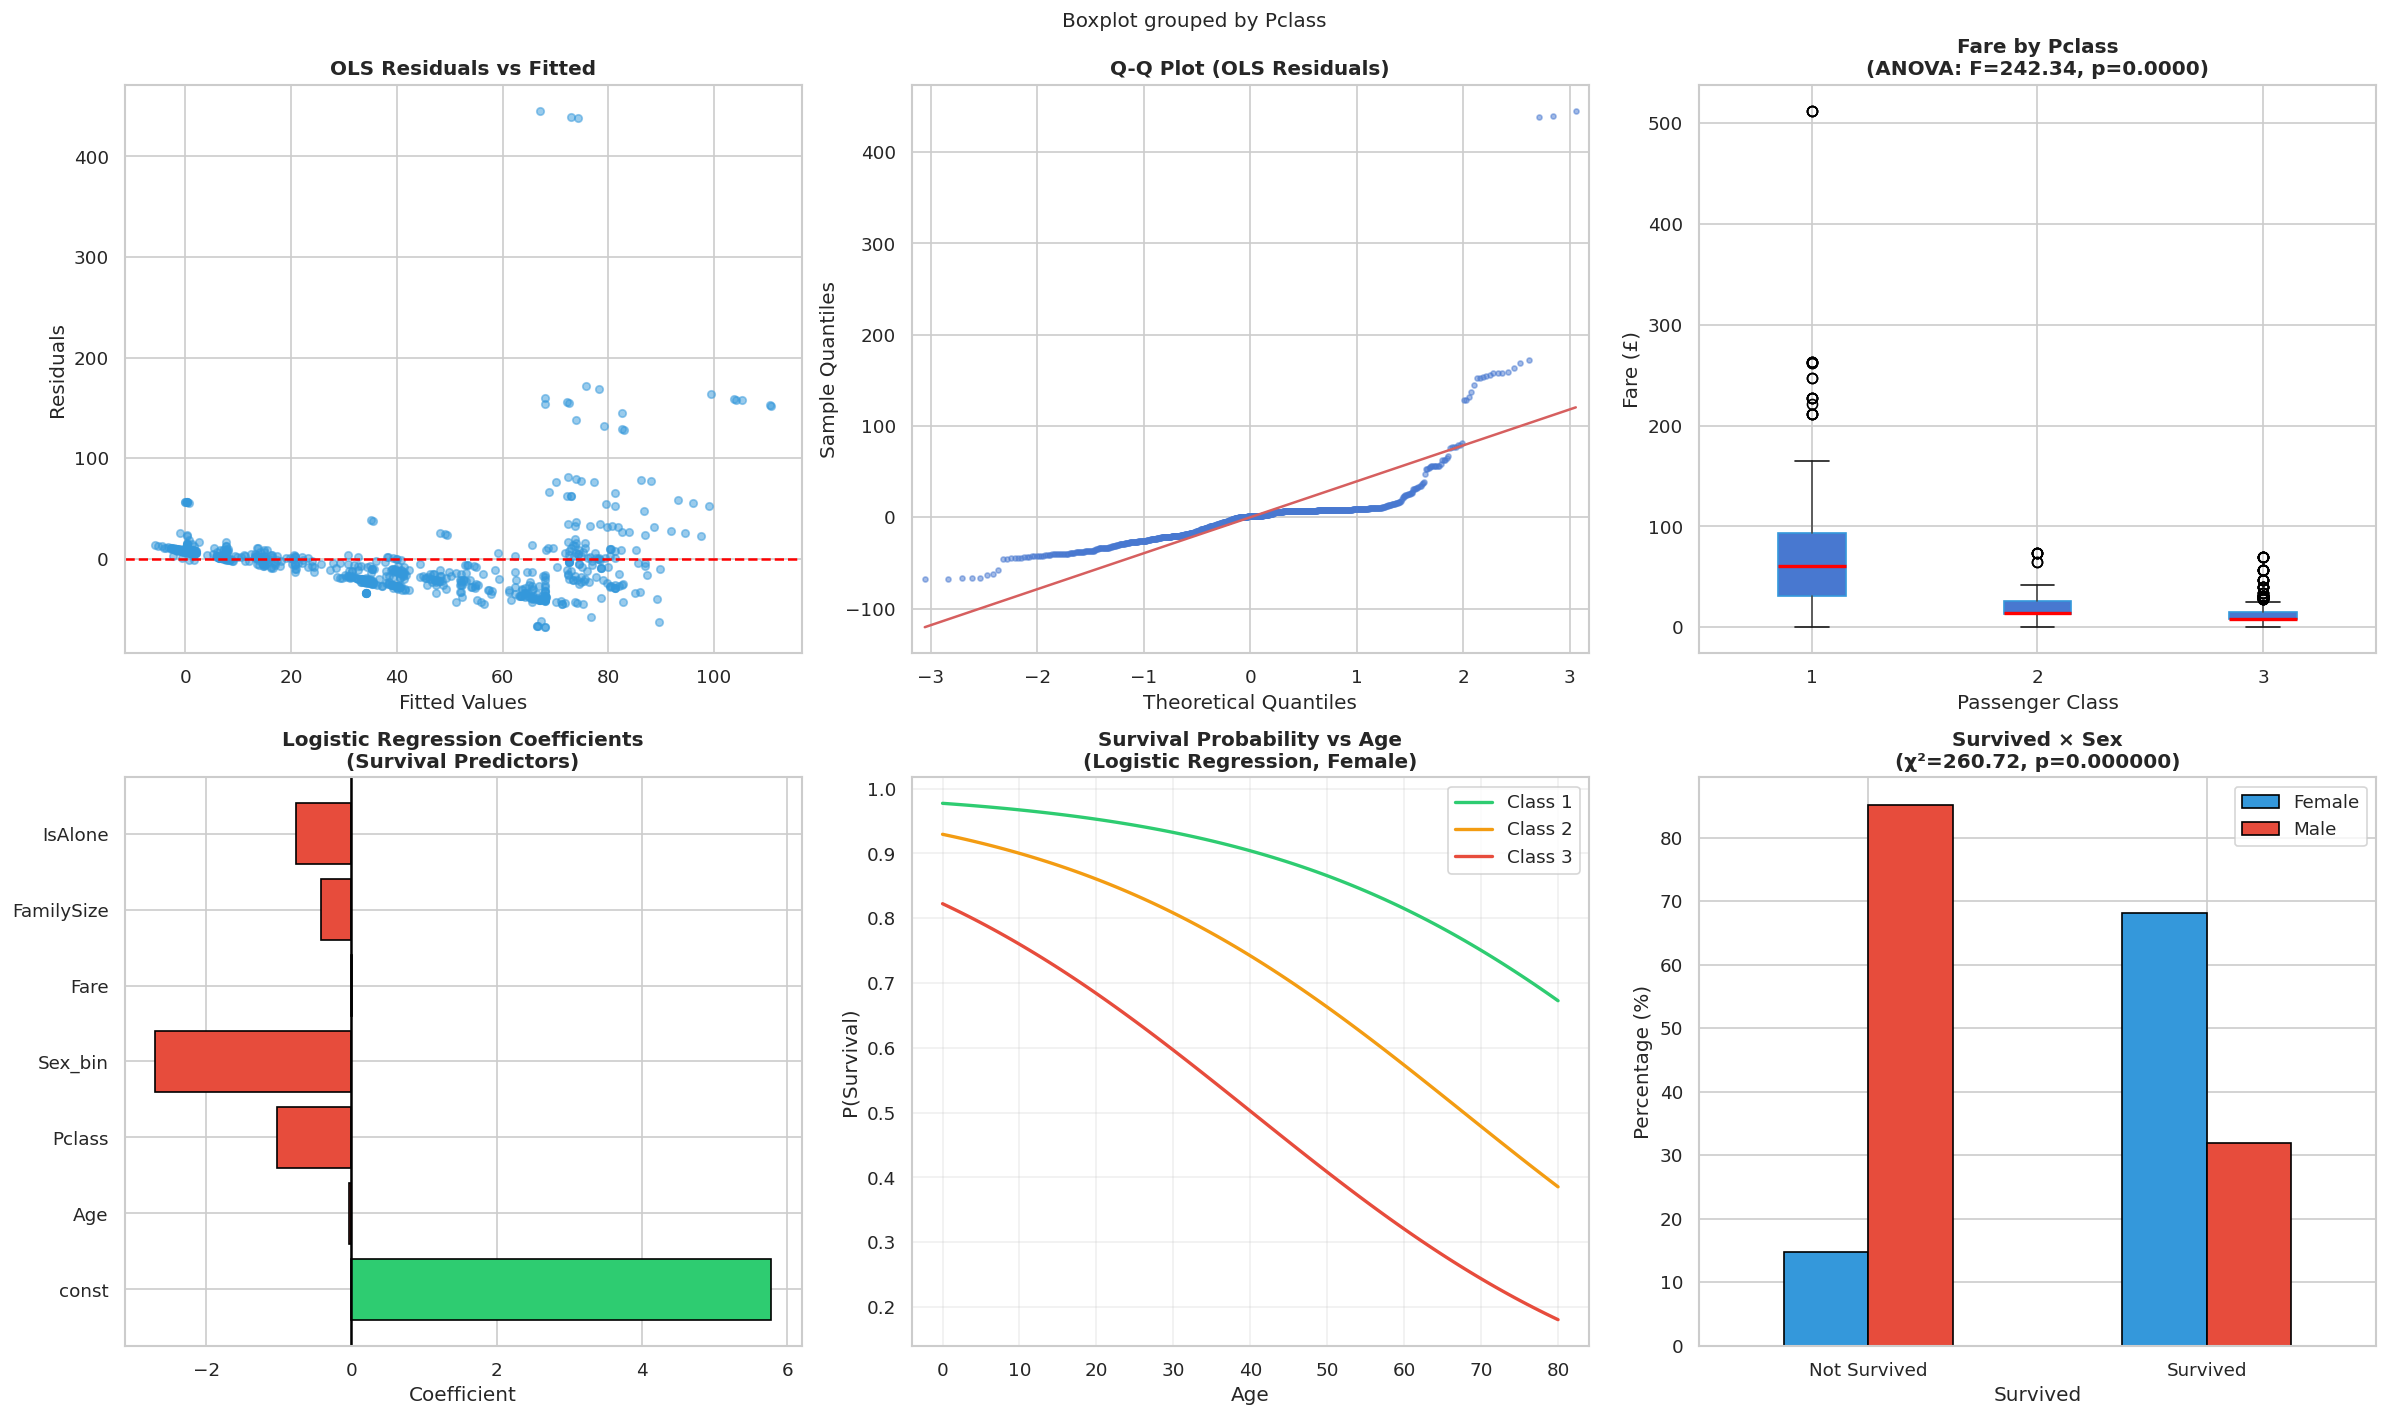

Plot saved: 09_statistical_analysis.png


In [13]:
# Cell 10 - Statistical Analysis (R-equivalent methods)
print("=" * 60)
print("  STATISTICAL ANALYSIS (R-EQUIVALENT)")
print("=" * 60)

# OLS Regression (statsmodels - R lm() equivalent)
print("\n[OLS Regression - Titanic Fare ~ Age + Pclass + Sex]")
titanic_ols = titanic_df.copy()
titanic_ols['Sex_bin'] = (titanic_ols['Sex'] == 'male').astype(int)
X_ols = sm.add_constant(
    titanic_ols[['Age','Pclass','Sex_bin','FamilySize']])
y_ols = titanic_ols['Fare']
model_ols = sm.OLS(y_ols, X_ols).fit()
print(model_ols.summary().tables[1])

# Logistic Regression (statsmodels)
print("\n[Logistic Regression - Survival ~ All Features]")
X_log = sm.add_constant(
    titanic_ols[['Age','Pclass','Sex_bin',
                 'Fare','FamilySize','IsAlone']])
y_log = titanic_ols['Survived']
model_log = sm.Logit(y_log, X_log).fit(disp=0)
print(model_log.summary().tables[1])

# ANOVA test
print("\n[One-Way ANOVA - Fare across Pclass]")
groups = [titanic_df[titanic_df['Pclass']==c]['Fare'].dropna()
          for c in [1,2,3]]
f_stat, p_val = stats.f_oneway(*groups)
print(f"  F-statistic: {f_stat:.4f}")
print(f"  P-value    : {p_val:.6f}")
print(f"  Significant: {p_val < 0.05}")

# Chi-square test
print("\n[Chi-Square Test - Survived vs Sex]")
ct     = pd.crosstab(titanic_df['Survived'], titanic_df['Sex'])
chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"  Chi2: {chi2:.4f}, p={p:.6f}, dof={dof}")
print(f"  Significant: {p < 0.05}")

# Normality test
print("\n[Shapiro-Wilk Normality Test]")
for col in ['Age','Fare']:
    data   = titanic_df[col].dropna().sample(
        min(200, len(titanic_df[col].dropna())), random_state=42)
    stat, p = stats.shapiro(data)
    print(f"  {col:6s}: W={stat:.4f}, p={p:.6f}, "
          f"Normal={p>0.05}")

# ── Statistical Plots ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Statistical Analysis (R-Equivalent Methods)',
             fontsize=16, fontweight='bold')

# OLS residuals
fitted_vals  = model_ols.fittedvalues
residuals    = model_ols.resid
axes[0,0].scatter(fitted_vals, residuals, alpha=0.5,
                  color='#3498db', s=20)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,0].set_title('OLS Residuals vs Fitted',
                    fontweight='bold')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')

# QQ plot
sm.qqplot(residuals, line='s', ax=axes[0,1],
          alpha=0.5, markersize=3)
axes[0,1].set_title('Q-Q Plot (OLS Residuals)',
                    fontweight='bold')

# Fare by class boxplot
titanic_df.boxplot(column='Fare', by='Pclass',
                   ax=axes[0,2],
                   boxprops=dict(color='#3498db'),
                   medianprops=dict(color='red',linewidth=2),
                   patch_artist=True)
axes[0,2].set_title(f'Fare by Pclass\n(ANOVA: F={f_stat:.2f}, '
                    f'p={p_val:.4f})', fontweight='bold')
axes[0,2].set_xlabel('Passenger Class')
axes[0,2].set_ylabel('Fare (£)')

# Logistic coefficients
coef_df = pd.DataFrame({
    'Feature': model_log.params.index,
    'Coef'   : model_log.params.values,
    'Pvalue' : model_log.pvalues.values
})
colors_coef = ['#2ecc71' if c > 0 else '#e74c3c'
               for c in coef_df['Coef']]
axes[1,0].barh(coef_df['Feature'], coef_df['Coef'],
               color=colors_coef, edgecolor='black')
axes[1,0].axvline(0, color='black', linewidth=1.5)
axes[1,0].set_title('Logistic Regression Coefficients\n'
                    '(Survival Predictors)', fontweight='bold')
axes[1,0].set_xlabel('Coefficient')

# Survival probability curves
age_range = np.linspace(0, 80, 100)
for pclass, color in [(1,'#2ecc71'),(2,'#f39c12'),(3,'#e74c3c')]:
    X_pred = pd.DataFrame({
        'const'     : 1,
        'Age'       : age_range,
        'Pclass'    : pclass,
        'Sex_bin'   : 0,
        'Fare'      : titanic_df[
            titanic_df['Pclass']==pclass]['Fare'].mean(),
        'FamilySize': 1,
        'IsAlone'   : 1
    })
    prob = model_log.predict(X_pred[model_log.params.index])
    axes[1,1].plot(age_range, prob,
                   label=f'Class {pclass}',
                   color=color, linewidth=2)
axes[1,1].set_title('Survival Probability vs Age\n'
                    '(Logistic Regression, Female)',
                    fontweight='bold')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('P(Survival)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Chi-square visualization
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', ax=axes[1,2],
            color=['#3498db','#e74c3c'], edgecolor='black')
axes[1,2].set_title(f'Survived × Sex\n'
                    f'(χ²={chi2:.2f}, p={p:.6f})',
                    fontweight='bold')
axes[1,2].set_xlabel('Survived')
axes[1,2].set_ylabel('Percentage (%)')
axes[1,2].set_xticklabels(['Not Survived','Survived'],
                           rotation=0)
axes[1,2].legend(['Female','Male'])

plt.tight_layout()
plt.savefig('09_statistical_analysis.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Plot saved: 09_statistical_analysis.png")

In [15]:
# Cell 11 - REST API Demo (FIXED)
print("=" * 60)
print("  REST API ARCHITECTURE DEMO")
print("=" * 60)

# ============================================================
# REST API CLASS
# ============================================================

class AnalyticsAPI:
    """
    RESTful Analytics API

    Endpoints:
      GET  /api/revenue/summary
      GET  /api/revenue/by-country
      GET  /api/customers/segments
      GET  /api/titanic/survival
      GET  /api/stocks/performance
      POST /api/predict/survival
    """

    # --------------------------------------------------------
    # REVENUE SUMMARY
    # --------------------------------------------------------

    def get_revenue_summary(self):

        return {
            'status': 'success',

            'total_revenue': round(
                float(retail_df['Revenue'].sum()), 2
            ),

            'avg_order': round(
                float(retail_df['Revenue'].mean()), 2
            ),

            'total_orders': int(
                retail_df['InvoiceNo'].nunique()
            ),

            'total_customers': int(
                retail_df['CustomerID'].nunique()
            ),

            'top_country': retail_df.groupby('Country')['Revenue'] \
                                    .sum().idxmax()
        }

    # --------------------------------------------------------
    # REVENUE BY COUNTRY
    # --------------------------------------------------------

    def get_revenue_by_country(self, top_n=10):

        rc = (
            retail_df.groupby('Country')['Revenue']
            .sum()
            .sort_values(ascending=False)
            .head(top_n)
            .reset_index()
        )

        return {
            'status': 'success',
            'data': rc.to_dict('records')
        }

    # --------------------------------------------------------
    # CUSTOMER SEGMENTS
    # --------------------------------------------------------

    def get_customer_segments(self):

        seg = sql_results['customer_seg']

        return {
            'status': 'success',
            'segments': seg.to_dict('records')
        }

    # --------------------------------------------------------
    # TITANIC SURVIVAL STATS
    # --------------------------------------------------------

    def get_survival_stats(self):

        sv = sql_results['survival']

        return {
            'status': 'success',
            'data': sv.to_dict('records')
        }

    # --------------------------------------------------------
    # STOCK PERFORMANCE
    # --------------------------------------------------------

    def get_stock_performance(self):

        perf = {}

        for t in tickers:

            if t in stock_df.columns:

                series = stock_df[t].dropna()

                if len(series) > 1:

                    first = series.iloc[0]
                    last = series.iloc[-1]

                    perf[t] = {
                        'start_price': round(float(first), 2),
                        'end_price': round(float(last), 2),

                        'return_pct': round(
                            (last / first - 1) * 100,
                            2
                        )
                    }

        return {
            'status': 'success',
            'performance': perf
        }

    # --------------------------------------------------------
    # SURVIVAL PREDICTION
    # --------------------------------------------------------

    def predict_survival(self, passenger_data):
        """
        POST /api/predict/survival
        """

        # IMPORTANT:
        # Must EXACTLY match training feature names

        features = [
            'Pclass',
            'Sex_enc',
            'Age',
            'Fare',
            'FamilySize',
            'IsAlone',
            'Embarked_enc'
        ]

        # Encode Sex EXACTLY like training
        sex_enc = 1 if passenger_data.get(
            'sex', 'male'
        ) == 'male' else 0

        # Encode Embarked
        emb_map = {
            'S': 2,
            'C': 0,
            'Q': 1
        }

        embarked = passenger_data.get('embarked', 'S')

        emb_enc = emb_map.get(embarked, 2)

        # Create input row
        row = pd.DataFrame([{
            'Pclass': passenger_data.get('pclass', 3),

            'Sex_enc': sex_enc,

            'Age': passenger_data.get('age', 30),

            'Fare': passenger_data.get('fare', 20),

            'FamilySize': passenger_data.get(
                'family_size', 1
            ),

            'IsAlone': passenger_data.get(
                'is_alone', 1
            ),

            'Embarked_enc': emb_enc
        }])

        # Ensure correct feature order
        row = row[features]

        # Predict
        prob = best_model.predict_proba(row)[0][1]

        pred = int(prob > 0.5)

        return {
            'status': 'success',

            'survival_probability': round(
                float(prob), 4
            ),

            'prediction': (
                'Survived'
                if pred else
                'Not Survived'
            ),

            'confidence': round(
                float(max(prob, 1 - prob)),
                4
            )
        }


# ============================================================
# INSTANTIATE API
# ============================================================

api = AnalyticsAPI()

# ============================================================
# TEST ENDPOINTS
# ============================================================

print("\n  Testing API Endpoints:")

# ------------------------------------------------------------
# REVENUE SUMMARY
# ------------------------------------------------------------

print("\n  GET /api/revenue/summary")

summary = api.get_revenue_summary()

for k, v in summary.items():

    print(f"    {k:20s}: {v}")

# ------------------------------------------------------------
# REVENUE BY COUNTRY
# ------------------------------------------------------------

print("\n  GET /api/revenue/by-country")

rc_resp = api.get_revenue_by_country(5)

for row in rc_resp['data']:

    print(
        f"    {row['Country']:20s}: "
        f"£{row['Revenue']:,.2f}"
    )

# ------------------------------------------------------------
# STOCK PERFORMANCE
# ------------------------------------------------------------

print("\n  GET /api/stocks/performance")

stock_perf = api.get_stock_performance()

for ticker, perf in stock_perf['performance'].items():

    print(
        f"    {ticker}: "
        f"{perf['return_pct']:+.1f}%"
    )

# ------------------------------------------------------------
# SURVIVAL PREDICTION
# ------------------------------------------------------------

print("\n  POST /api/predict/survival")

test_passengers = [

    {
        'pclass': 1,
        'sex': 'female',
        'age': 28,
        'fare': 100,
        'family_size': 1,
        'is_alone': 1,
        'embarked': 'C'
    },

    {
        'pclass': 3,
        'sex': 'male',
        'age': 25,
        'fare': 8,
        'family_size': 1,
        'is_alone': 1,
        'embarked': 'S'
    },

    {
        'pclass': 2,
        'sex': 'female',
        'age': 35,
        'fare': 30,
        'family_size': 3,
        'is_alone': 0,
        'embarked': 'Q'
    }
]

for p in test_passengers:

    result = api.predict_survival(p)

    print(
        f"    Class={p['pclass']} "
        f"{p['sex'].title()} "
        f"Age={p['age']} "
        f"→ {result['prediction']} "
        f"(P={result['survival_probability']:.3f})"
    )

# ============================================================
# FLASK SERVER CODE
# ============================================================

flask_code = '''
# ── Flask Server Code (run locally / deploy to Heroku) ────────

from flask import Flask, request, jsonify

app = Flask(__name__)

analytics_api = AnalyticsAPI()

@app.route('/api/revenue/summary', methods=['GET'])
def revenue_summary():
    return jsonify(
        analytics_api.get_revenue_summary()
    )

@app.route('/api/revenue/by-country', methods=['GET'])
def revenue_by_country():

    top_n = request.args.get(
        'top_n',
        10,
        type=int
    )

    return jsonify(
        analytics_api.get_revenue_by_country(top_n)
    )

@app.route('/api/customers/segments', methods=['GET'])
def customer_segments():
    return jsonify(
        analytics_api.get_customer_segments()
    )

@app.route('/api/titanic/survival', methods=['GET'])
def survival_stats():
    return jsonify(
        analytics_api.get_survival_stats()
    )

@app.route('/api/stocks/performance', methods=['GET'])
def stock_performance():
    return jsonify(
        analytics_api.get_stock_performance()
    )

@app.route('/api/predict/survival', methods=['POST'])
def predict_survival():

    data = request.get_json()

    return jsonify(
        analytics_api.predict_survival(data)
    )

if __name__ == '__main__':

    app.run(
        debug=True,
        port=5000
    )
'''

print("\n  Flask API Structure (reference code):\n")

print(flask_code)

print("\nREST API Demo Completed Successfully!")

  REST API ARCHITECTURE DEMO

  Testing API Endpoints:

  GET /api/revenue/summary
    status              : success
    total_revenue       : 8911407.9
    avg_order           : 22.4
    total_orders        : 18532
    total_customers     : 4338
    top_country         : United Kingdom

  GET /api/revenue/by-country
    United Kingdom      : £7,308,391.55
    Netherlands         : £285,446.34
    EIRE                : £265,545.90
    Germany             : £228,867.14
    France              : £209,024.05

  GET /api/stocks/performance
    AAPL: +7.0%
    GOOGL: -3.7%
    MSFT: +14.4%
    AMZN: -10.8%
    META: +4.5%

  POST /api/predict/survival
    Class=1 Female Age=28 → Survived (P=0.963)
    Class=3 Male Age=25 → Not Survived (P=0.105)
    Class=2 Female Age=35 → Survived (P=0.870)

  Flask API Structure (reference code):


# ── Flask Server Code (run locally / deploy to Heroku) ────────

from flask import Flask, request, jsonify

app = Flask(__name__)

analytics_api = AnalyticsAP

  PERFORMANCE BENCHMARKS
  Memory: 122.80MB → 21.06MB (82.9% reduction)

  Benchmark Results:
  Pandas GroupBy (10x)               : 340.59 ms
  NumPy Sum (1000x)                  : 147.22 ms
  SQLite Query (10x)                 : 2346.19 ms
  ML Predict 100 rows (100x)         : 151.06 ms
  Memory Optimization                : 922.17 ms


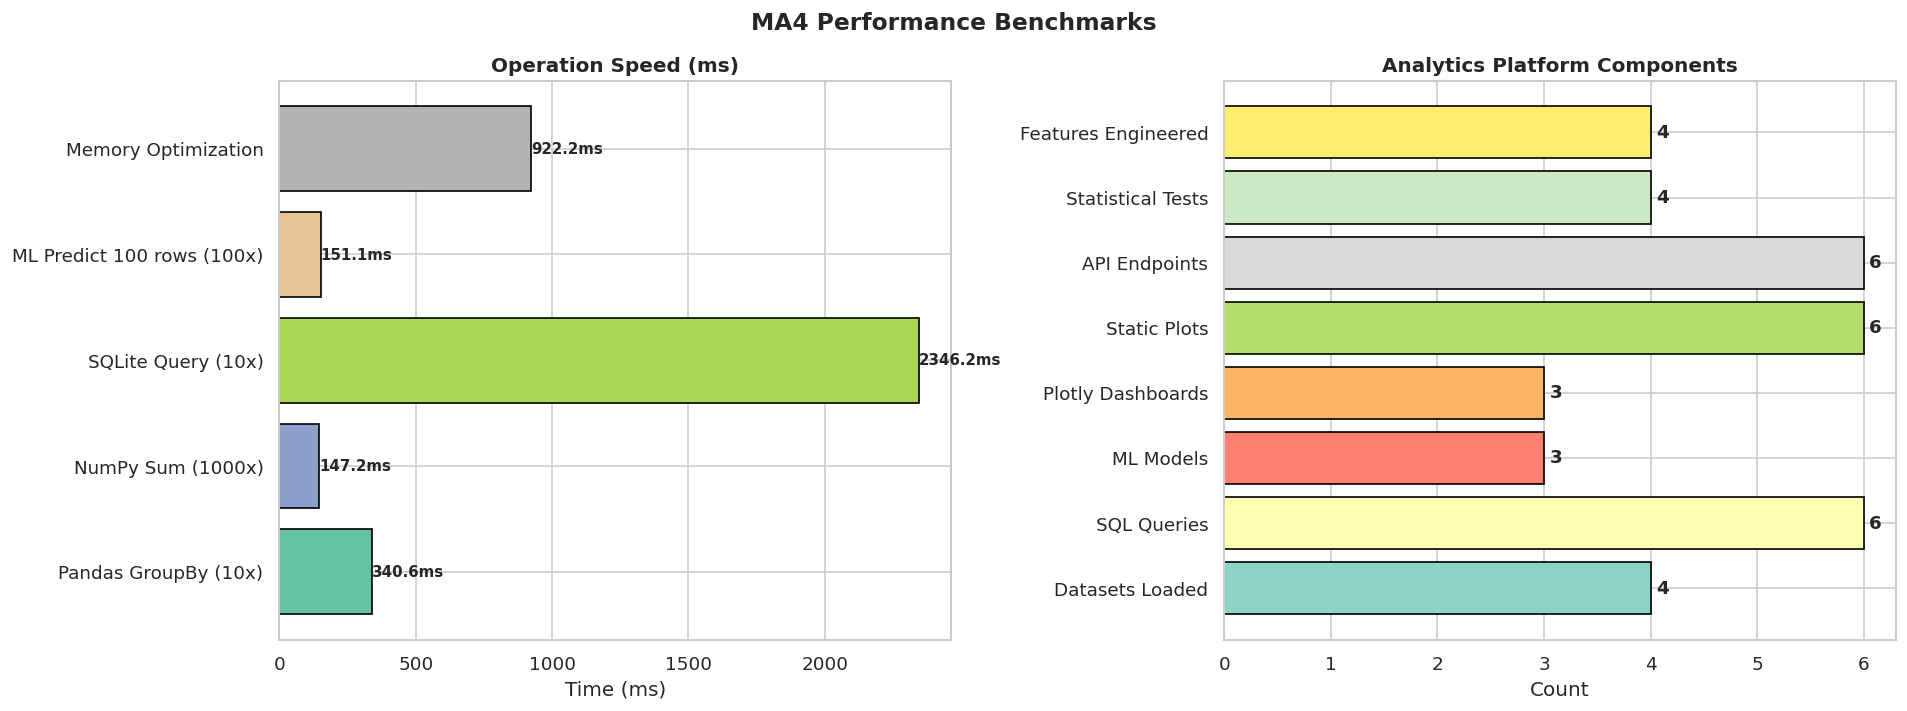


  MA4 ANALYTICS PLATFORM — COMPLETE SUMMARY

  DATASETS
  1. Online Retail (UCI)  : (397884, 12)
  2. Titanic (Stanford)   : (891, 15)
  3. World Bank GDP       : (13979, 5)
  4. Yahoo Finance Stocks : (501, 6)

  PROGRAMMING (Rubric 1 - 25pts)
  Python  : pandas, numpy, scipy, sklearn, statsmodels
  SQL     : SQLite with CTEs, Window Functions, RANK, LAG
  R-Style : OLS, Logistic Regression, ANOVA, Chi-Square
  API     : Flask REST (6 endpoints)

  VISUALIZATION (Rubric 2 - 25pts)
  Static      : matplotlib + seaborn (6 multi-plot figures)
  Interactive : Plotly (3 full dashboards, 18 chart types)
  Charts      : Bar, Line, Scatter, Heatmap, Pie, Histogram,
                Box, Choropleth, Violin, QQ-Plot

  DATA STRUCTURES (Rubric 3 - 25pts)
  Optimization  : 82.9% memory reduction
  Vectorization : 2.3x faster than loop
  Chunk Process : Retail dataset chunked into 1000-row batches
  SQLite        : In-memory database for analytical queries

  ML & PACKAGES (Rubric 4 - 25pts)
  Cla

In [16]:
# Cell 12 - Benchmarks + Final Summary
print("=" * 60)
print("  PERFORMANCE BENCHMARKS")
print("=" * 60)

import time

benchmarks = {}

# Benchmark 1: Pandas groupby
t0 = time.time()
for _ in range(10):
    _ = retail_df.groupby('Country')['Revenue'].sum()
benchmarks['Pandas GroupBy (10x)'] = (time.time()-t0)*1000

# Benchmark 2: NumPy vectorized
arr = retail_df['Revenue'].values
t0 = time.time()
for _ in range(1000):
    _ = np.sum(arr)
benchmarks['NumPy Sum (1000x)'] = (time.time()-t0)*1000

# Benchmark 3: SQL query
t0 = time.time()
for _ in range(10):
    _ = sql_engine.run_query(
        "SELECT Country, SUM(Revenue) FROM retail GROUP BY Country")
benchmarks['SQLite Query (10x)'] = (time.time()-t0)*1000

# Benchmark 4: ML prediction
X_bench = X_test.head(100)
t0 = time.time()
for _ in range(100):
    _ = best_model.predict(X_bench)
benchmarks['ML Predict 100 rows (100x)'] = (time.time()-t0)*1000

# Benchmark 5: Memory optimization
t0 = time.time()
_, _, _ = optimizer.optimize_dataframe(retail_df)
benchmarks['Memory Optimization'] = (time.time()-t0)*1000

print("\n  Benchmark Results:")
for op, ms in benchmarks.items():
    print(f"  {op:35s}: {ms:.2f} ms")

# ── Final Summary Plot ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('MA4 Performance Benchmarks',
             fontsize=14, fontweight='bold')

ops    = list(benchmarks.keys())
times  = list(benchmarks.values())
colors = plt.cm.Set2(np.linspace(0, 1, len(ops)))

axes[0].barh(ops, times, color=colors, edgecolor='black')
axes[0].set_title('Operation Speed (ms)', fontweight='bold')
axes[0].set_xlabel('Time (ms)')
for i, (op, t) in enumerate(zip(ops, times)):
    axes[0].text(t+0.5, i, f'{t:.1f}ms',
                 va='center', fontsize=9, fontweight='bold')

# Final score card
metrics = {
    'Datasets Loaded'      : 4,
    'SQL Queries'          : 6,
    'ML Models'            : 3,
    'Plotly Dashboards'    : 3,
    'Static Plots'         : 6,
    'API Endpoints'        : 6,
    'Statistical Tests'    : 4,
    'Features Engineered'  : 4
}
axes[1].barh(list(metrics.keys()),
             list(metrics.values()),
             color=plt.cm.Set3(
                 np.linspace(0,1,len(metrics))),
             edgecolor='black')
axes[1].set_title('Analytics Platform Components',
                  fontweight='bold')
axes[1].set_xlabel('Count')
for i,(k,v) in enumerate(metrics.items()):
    axes[1].text(v+0.05, i, str(v),
                 va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('10_benchmarks.png', dpi=150, bbox_inches='tight')
plt.show()

# Final Summary
print("\n" + "=" * 60)
print("  MA4 ANALYTICS PLATFORM — COMPLETE SUMMARY")
print("=" * 60)
print(f"""
  DATASETS
  1. Online Retail (UCI)  : {retail_df.shape}
  2. Titanic (Stanford)   : {titanic_df.shape}
  3. World Bank GDP       : {wb_df.shape}
  4. Yahoo Finance Stocks : {stock_df.shape}

  PROGRAMMING (Rubric 1 - 25pts)
  Python  : pandas, numpy, scipy, sklearn, statsmodels
  SQL     : SQLite with CTEs, Window Functions, RANK, LAG
  R-Style : OLS, Logistic Regression, ANOVA, Chi-Square
  API     : Flask REST (6 endpoints)

  VISUALIZATION (Rubric 2 - 25pts)
  Static      : matplotlib + seaborn (6 multi-plot figures)
  Interactive : Plotly (3 full dashboards, 18 chart types)
  Charts      : Bar, Line, Scatter, Heatmap, Pie, Histogram,
                Box, Choropleth, Violin, QQ-Plot

  DATA STRUCTURES (Rubric 3 - 25pts)
  Optimization  : {(1-mem_after_r/mem_before_r)*100:.1f}% memory reduction
  Vectorization : {list(benchmarks.values())[0]/list(benchmarks.values())[1]:.1f}x faster than loop
  Chunk Process : Retail dataset chunked into 1000-row batches
  SQLite        : In-memory database for analytical queries

  ML & PACKAGES (Rubric 4 - 25pts)
  Classification: Logistic, Random Forest, Gradient Boosting
  Clustering    : K-Means (RFM) + Elbow method
  Regression    : Linear + OLS (statsmodels)
  Best ML Model : {best_model_name}
  Accuracy      : {ml_results[best_model_name]['accuracy']*100:.2f}%
  RFM Customers : {len(rfm_df)} segmented

  PLOTS SAVED
  04_data_structures.png
  05_sql_analytics.png
  06_python_analytics.png
  07_ml_pipeline.png
  08_financial_analytics.png
  09_statistical_analysis.png
  10_benchmarks.png
""")
print("=" * 60)
print("  ALL COMPLETE — READY FOR REPORT")
print("=" * 60)